In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import KFold, GridSearchCV, cross_val_predict
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

PROJECT_ROOT = Path().resolve().parent.parent
DATA_DIR = PROJECT_ROOT / "data"

RESULT_DIR = PROJECT_ROOT / "src" / "5th_Year_Salary_Analysis" / "Result"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# Makeing the salary_CAP_Percentage

In [2]:
# 1. read the final input file
df = pd.read_csv(RESULT_DIR / "df_with_archetype_matched.csv")

# 2. make sure salary columns are numeric
df["salary"] = pd.to_numeric(df["salary"], errors="coerce")
df["salary_cap"] = pd.to_numeric(df["salary_cap"], errors="coerce")

# 3. create salary cap percentage
df["salary_cap_pct"] = df["salary"] / df["salary_cap"]

# 4. optional: percentage on 0-100 scale
df["salary_cap_pct_100"] = df["salary_cap_pct"] * 100

# 5. check result
print(df[["player_name_fixed", "year", "salary", "salary_cap", "salary_cap_pct", "salary_cap_pct_100"]].head(20))
print("\nMissing salary_cap_pct rows:", df["salary_cap_pct"].isna().sum())
print("Shape:", df.shape)

   player_name_fixed  year     salary   salary_cap  salary_cap_pct  \
0           AJ Price  2009   457588.0   57700000.0        0.007930   
1           AJ Price  2010   762195.0   58044000.0        0.013131   
2           AJ Price  2011   854389.0   58044000.0        0.014720   
3           AJ Price  2012   885120.0   58044000.0        0.015249   
4       Aaron Brooks  2007   972720.0   55630000.0        0.017486   
5       Aaron Brooks  2008  1045560.0   58680000.0        0.017818   
6       Aaron Brooks  2009  1118520.0   57700000.0        0.019385   
7       Aaron Brooks  2010  2016692.0   58044000.0        0.034744   
8       Aaron Gordon  2014  3992040.0   63065000.0        0.063300   
9       Aaron Gordon  2015  4171680.0   70000000.0        0.059595   
10      Aaron Gordon  2016  4351320.0   94143000.0        0.046220   
11      Aaron Gordon  2017  5504419.0   99093000.0        0.055548   
12        Aaron Gray  2007   427163.0   55630000.0        0.007679   
13        Aaron Gray

In [3]:
# --------------------------------------------------
# 1. read the two files
# --------------------------------------------------
df_x = df   # first 4 years info
df_y = pd.read_csv(RESULT_DIR / "df_y5.csv")


# standardize column names
df_x.columns = df_x.columns.str.strip().str.lower()
df_y.columns = df_y.columns.str.strip().str.lower()

print("df_x shape:", df_x.shape)
print("df_y shape:", df_y.shape)
print(df_x.columns.tolist())
print(df_y.columns.tolist())

df_x shape: (2240, 51)
df_y shape: (899, 6)
['player_id', 'player_name_fixed', 'year', 'team_id', 'team_abbreviation', 'age', 'gp', 'w', 'l', 'w_pct', 'min', 'fgm', 'fga', 'fg_pct', 'fg3m', 'fg3a', 'fg3_pct', 'ftm', 'fta', 'ft_pct', 'oreb', 'dreb', 'reb', 'ast', 'tov', 'stl', 'blk', 'blka', 'pf', 'pfd', 'pts', 'plus_minus', 'nba_fantasy_pts', 'dd2', 'td3', 'wnba_fantasy_pts', 'team_count', 'performance_score', 'salary', 'salary_cap', 'n_years_played', 'predicted_class', 'prob_bust', 'prob_neutral', 'prob_sleeper', 'max_pred_prob', 'macro_archetype', 'shot_style_subtype', 'lstm_confidence', 'salary_cap_pct', 'salary_cap_pct_100']
['player_id', 'player_name_fixed', 'year', 'salary', 'salary_cap', 'salary_cap_pct']


In [4]:
# --------------------------------------------------
# 2. sort X table and assign season order within player
# --------------------------------------------------
df_x = df_x.sort_values(["player_name_fixed", "year"]).copy()

# only keep players with at least 4 rows in X
player_counts_x = (
    df_x.groupby("player_name_fixed")["year"]
    .nunique()
    .reset_index(name="n_years_x")
)

valid_players_x = player_counts_x.loc[
    player_counts_x["n_years_x"] >= 4,
    "player_name_fixed"
]

df_x = df_x[df_x["player_name_fixed"].isin(valid_players_x)].copy()

# season order: 1,2,3,4,...
df_x["season_num"] = df_x.groupby("player_name_fixed").cumcount() + 1

# keep only first 4 years as inputs
df_x4 = df_x[df_x["season_num"] <= 4].copy()

# make sure each player has exactly 4 kept rows
check4 = (
    df_x4.groupby("player_name_fixed")
    .size()
    .reset_index(name="n_rows")
)

valid_players_4 = check4.loc[check4["n_rows"] == 4, "player_name_fixed"]
df_x4 = df_x4[df_x4["player_name_fixed"].isin(valid_players_4)].copy()

print("Players with 4 usable input years:", df_x4["player_name_fixed"].nunique())
print(df_x4[["player_name_fixed", "year", "season_num"]].head(20))

Players with 4 usable input years: 560
   player_name_fixed  year  season_num
0           AJ Price  2009           1
1           AJ Price  2010           2
2           AJ Price  2011           3
3           AJ Price  2012           4
4       Aaron Brooks  2007           1
5       Aaron Brooks  2008           2
6       Aaron Brooks  2009           3
7       Aaron Brooks  2010           4
8       Aaron Gordon  2014           1
9       Aaron Gordon  2015           2
10      Aaron Gordon  2016           3
11      Aaron Gordon  2017           4
12        Aaron Gray  2007           1
13        Aaron Gray  2008           2
14        Aaron Gray  2009           3
15        Aaron Gray  2010           4
16     Aaron Holiday  2018           1
17     Aaron Holiday  2019           2
18     Aaron Holiday  2020           3
19     Aaron Holiday  2021           4


In [5]:
# --------------------------------------------------
# 3. build y_df from df_y
# --------------------------------------------------
# make sure salary columns are numeric
df_y["salary"] = pd.to_numeric(df_y["salary"], errors="coerce")
df_y["salary_cap"] = pd.to_numeric(df_y["salary_cap"], errors="coerce")

# create salary_cap_pct if not already present
if "salary_cap_pct" not in df_y.columns:
    df_y["salary_cap_pct"] = df_y["salary"] / df_y["salary_cap"]

# keep only needed columns for target
y_df = df_y[["player_name_fixed", "year", "salary", "salary_cap", "salary_cap_pct"]].copy()

# rename target columns
y_df = y_df.rename(columns={
    "year": "target_year",
    "salary_cap_pct": "salary_cap_pct_y5"
})

print("y_df shape:", y_df.shape)
print(y_df.head())

# --------------------------------------------------
# 4. add lstm_confidence to df_x4 if missing
# --------------------------------------------------
if "lstm_confidence" not in df_x4.columns:
    final_lstm = pd.read_csv(DATA_DIR / "final_lstm_predictions_all_players.csv")
    final_lstm.columns = final_lstm.columns.str.strip().str.lower()

    possible_conf_cols = ["confidence", "max_pred_prob"]
    conf_col = None
    for c in possible_conf_cols:
        if c in final_lstm.columns:
            conf_col = c
            break

    if conf_col is None:
        raise ValueError(f"No confidence column found in final_lstm. Columns are: {final_lstm.columns.tolist()}")

    lstm_conf = final_lstm[["player_id", conf_col]].drop_duplicates(subset=["player_id"]).copy()
    lstm_conf = lstm_conf.rename(columns={conf_col: "lstm_confidence"})

    df_x4 = df_x4.merge(lstm_conf, on="player_id", how="left")

print("lstm_confidence in df_x4?", "lstm_confidence" in df_x4.columns)

y_df shape: (899, 5)
  player_name_fixed  target_year      salary   salary_cap  salary_cap_pct_y5
0          AJ Price         2013    947907.0   58679000.0           0.016154
1      Aaron Brooks         2012   5750000.0   58044000.0           0.099063
2      Aaron Gordon         2018  21590909.0  101869000.0           0.211948
3        Aaron Gray         2011   2500000.0   58044000.0           0.043071
4     Aaron Holiday         2022   1968175.0  123655000.0           0.015917
lstm_confidence in df_x4? True


# Ridge Regression + K-Fold Cross-Validation

In this section, we use **ridge regression** as one of the baseline models for predicting **fifth-year salary cap percentage**.

## Objective

The objective of this step is to evaluate how well a regularized linear regression model uses information from a player's first four seasons to predict their **fifth-year salary cap percentage**.

More specifically, we want to answer the following questions:

> Do early career performance, usage rate, salary history, grade information, and player type background explain the meaningful portion of fifth-year salary value?

## Why Ridge Regression?

We use ridge regression because the prediction dataset contains many relevant predictor variables, some of which are likely correlated with each other. For example:

- Annual versions of the same variable from year 1 to year 4

- Different performance metrics changing synchronously

- Possibly overlapping category probabilities and role-based variables

Ridge regression is very useful in this case because it penalizes the model coefficients, which helps to:

- Reduce overfitting

- Stabilize estimates

- Improve prediction accuracy when predictor variables are correlated

Unlike ordinary least squares, ridge regression preserves all predictor variables in the model but shrinks their coefficients toward zero.

## Input Data Used

The ridge regression model primarily uses the cleaned prediction tables prepared in the previous notebook, including:

- `df_with_archetype_matched.csv`

- `df_y5.csv`

Based on these files, we constructed a player-level regression dataset where:

- **Input features** are from the player's first four seasons

- **Target variable** is the player's **fifth-year salary cap percentage**

The model uses a wide-format player-level feature set, meaning each player occupies one row, with the first four seasons represented by different columns.

Depending on the model version, features may include:

- Historical data on salary cap percentage for the previous four years

- Historical data on performance ratings for the previous four years

- Win percentage or availability variables for the previous four years

- Category-based variables, such as predicted category and category probability

- Contextual variables, such as macro prototypes and shooting style subtypes

## This step involves:

We first prepare the final regression table as follows:

1. Reformat the data from the previous four seasons into a player-level wide format

2. Incorporate the target values ​​from the fifth year into the table

3. Select the feature set for the current model version

4. Remove rows with missing values ​​in required columns

Then, we fit a ridge regression model.

## We use **K-fold cross-validation** to evaluate the model more reliably.

K-fold cross-validation does not simply fit the model after a single split, but repeatedly divides the data into training and validation sets. This allows for a more stable evaluation of model performance and helps us choose tuning settings in a more objective way.

## Model 1 contain following features:

"w_pct", "performance_score", "salary_cap_pct", "gp" and feature from goal_1. (including the predict calss and probabily for each calss)

In [6]:
# year-varying continuous features
candidate_features = [
    "w_pct",
    "performance_score",
    "salary_cap_pct",
    "gp"
]

feature_cols = [c for c in candidate_features if c in df_x4.columns]

id_cols = ["player_name_fixed"]

X_wide = df_x4.pivot_table(
    index=id_cols,
    columns="season_num",
    values=feature_cols,
    aggfunc="first"
)

X_wide.columns = [f"{feat}_y{yr}" for feat, yr in X_wide.columns]
X_wide = X_wide.reset_index()

age_y4 = (
    df_x4[df_x4["season_num"] == 4][["player_name_fixed", "age"]]
    .drop_duplicates(subset=["player_name_fixed"])
    .copy()
)

age_y4["age_group"] = pd.cut(
    age_y4["age"],
    bins=[-float("inf"), 20, 22, 24, float("inf")],
    labels=["age_le_20", "age_21_22", "age_23_24", "age_25_plus"]
)

goal1_cols = [
    "player_name_fixed",
    "predicted_class",
    "prob_bust",
    "prob_neutral",
    "prob_sleeper",
    "lstm_confidence"
]

goal1_cols = [c for c in goal1_cols if c in df_x4.columns]

goal1_player = (
    df_x4[goal1_cols]
    .drop_duplicates(subset=["player_name_fixed"])
    .copy()
)

goal1_player = goal1_player.merge(
    age_y4[["player_name_fixed", "age_group"]],
    on="player_name_fixed",
    how="left"
)


model_df = (
    X_wide
    .merge(goal1_player, on="player_name_fixed", how="inner")
    .merge(y_df, on="player_name_fixed", how="inner")
)

print("Model dataframe shape:", model_df.shape)
print(model_df.head())

# one-hot encode only the categorical variable
model_df = pd.get_dummies(
    model_df,
    columns=["predicted_class", "lstm_confidence", "age_group"],
    drop_first=False
)

print(model_df.columns.tolist())

exclude_cols = ["player_name_fixed", "target_year", "salary", "salary_cap", "salary_cap_pct_y5"]
X_cols = [c for c in model_df.columns if c not in exclude_cols]

for c in X_cols:
    if model_df[c].dtype == "bool":
        model_df[c] = model_df[c].astype(int)
    else:
        model_df[c] = pd.to_numeric(model_df[c], errors="coerce")

model_df["salary_cap_pct_y5"] = pd.to_numeric(model_df["salary_cap_pct_y5"], errors="coerce")

model_df_clean = model_df.dropna(subset=X_cols + ["salary_cap_pct_y5"]).copy()

print("Clean model dataframe shape:", model_df_clean.shape)

X = model_df_clean[X_cols].copy()
y = model_df_clean["salary_cap_pct_y5"].copy()

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

param_grid = {
    "ridge__alpha": np.logspace(-4, 4, 50)
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=kf,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid.fit(X, y)

best_model = grid.best_estimator_
y_pred_cv = cross_val_predict(best_model, X, y, cv=kf, n_jobs=-1)

mse = mean_squared_error(y, y_pred_cv)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred_cv)
r2 = r2_score(y, y_pred_cv)

print("Best alpha:", grid.best_params_["ridge__alpha"])
print("RMSE:", rmse)
print("MAE:", mae)
print("R^2:", r2)

cv_results_ridge_goal1 = model_df_clean[["player_name_fixed", "target_year", "salary_cap_pct_y5"]].copy()
cv_results_ridge_goal1["pred_salary_cap_pct_y5"] = y_pred_cv
cv_results_ridge_goal1["error"] = cv_results_ridge_goal1["pred_salary_cap_pct_y5"] - cv_results_ridge_goal1["salary_cap_pct_y5"]
cv_results_ridge_goal1["abs_error"] = cv_results_ridge_goal1["error"].abs()

Model dataframe shape: (560, 27)
  player_name_fixed  gp_y1  gp_y2  gp_y3  gp_y4  performance_score_y1  \
0          AJ Price     56     50     44     57                 276.5   
1      Aaron Brooks     51     80     82     59                 168.7   
2      Aaron Gordon     47     78     80     58                 185.2   
3        Aaron Gray     61     56     32     41                 178.7   
4     Aaron Holiday     50     66     66     63                 193.7   

   performance_score_y2  performance_score_y3  performance_score_y4  \
0                 191.8                 132.1                 338.7   
1                 555.8                1038.2                 390.3   
2                 671.3                 754.4                 745.5   
3                 165.9                 102.5                 110.4   
4                 464.2                 302.1                 318.0   

   salary_cap_pct_y1  ...  predicted_class  prob_bust  prob_neutral  \
0           0.007930  ...     

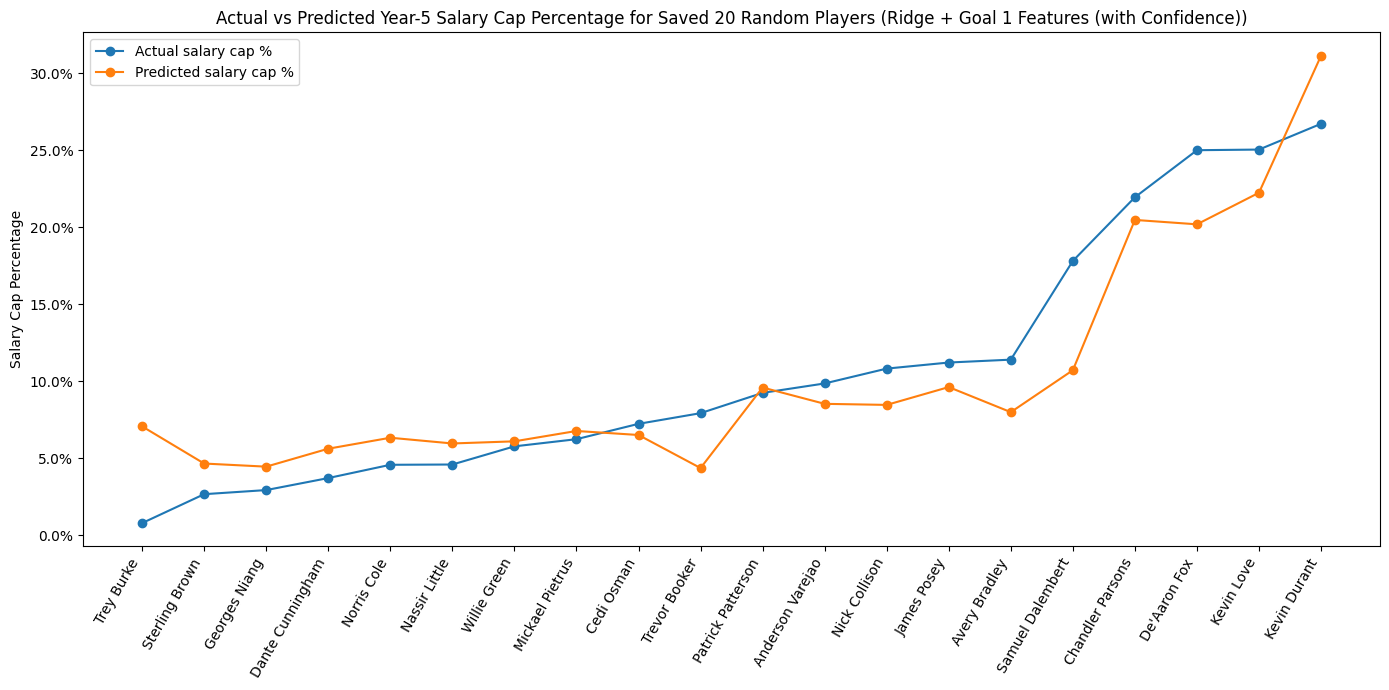

In [7]:
# randomly pick 20 players and save them
sample_20_players_ridge_goal1 = cv_results_ridge_goal1.sample(n=20, random_state=750).copy()
sample_20_players_ridge_goal1 = sample_20_players_ridge_goal1.sort_values("salary_cap_pct_y5").reset_index(drop=True)

plt.figure(figsize=(14, 7))

x = range(len(sample_20_players_ridge_goal1))

plt.plot(
    x,
    sample_20_players_ridge_goal1["salary_cap_pct_y5"],
    marker="o",
    label="Actual salary cap %"
)

plt.plot(
    x,
    sample_20_players_ridge_goal1["pred_salary_cap_pct_y5"],
    marker="o",
    label="Predicted salary cap %"
)

plt.xticks(
    x,
    sample_20_players_ridge_goal1["player_name_fixed"],
    rotation=60,
    ha="right"
)

plt.ylabel("Salary Cap Percentage")
plt.title("Actual vs Predicted Year-5 Salary Cap Percentage for Saved 20 Random Players (Ridge + Goal 1 Features (with Confidence))")
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.legend()
plt.tight_layout()
plt.show()

## Model 2 contain following features:

"w_pct", "performance_score", "salary_cap_pct", "gp" and feature from goal_1 (including the predict calss and probabily for each calss), feature from Goal2,  includes:    "prototype_fit_ambiguity", "macro_archetype", "shot_style_subtype"

In [8]:
block2 = pd.read_csv(PROJECT_ROOT / "Output" / "Player Archetype Analysis" / "SalaryBlock" /  "deliverable3_block2_archetype_comp_market_context.csv")
block2.columns = block2.columns.str.strip().str.lower()

block2_small = block2[
    ["player_id", "prototype_fit_ambiguity", "realistic_comp_similarity_mean"]
].drop_duplicates(subset=["player_id"]).copy()

df_x4 = df_x4.merge(
    block2_small,
    on="player_id",
    how="left"
)

print(df_x4[["player_id", "prototype_fit_ambiguity", "realistic_comp_similarity_mean"]].head())


   player_id  prototype_fit_ambiguity  realistic_comp_similarity_mean
0     201985                 0.631549                        5.125987
1     201985                 0.631549                        5.125987
2     201985                 0.631549                        5.125987
3     201985                 0.631549                        5.125987
4     201166                 0.595143                        5.306916


In [9]:
# --------------------------------------------------
# Model 3: Ridge + Goal 1 + Goal 2
# build model table
# --------------------------------------------------

# 1. year-varying continuous features only
candidate_features = [
    "w_pct",
    "performance_score",
    "salary_cap_pct",
    "gp"
]

feature_cols = [c for c in candidate_features if c in df_x4.columns]
print("Year-varying features used:", feature_cols)

# 2. pivot year-varying features to _y1 ... _y4
id_cols = ["player_name_fixed"]

X_wide = df_x4.pivot_table(
    index=id_cols,
    columns="season_num",
    values=feature_cols,
    aggfunc="first"
)

X_wide.columns = [f"{feat}_y{yr}" for feat, yr in X_wide.columns]
X_wide = X_wide.reset_index()

print(X_wide.head())

# 3. build age_group from year 4 age
age_y4 = (
    df_x4[df_x4["season_num"] == 4][["player_name_fixed", "age"]]
    .drop_duplicates(subset=["player_name_fixed"])
    .copy()
)

age_y4["age_group"] = pd.cut(
    age_y4["age"],
    bins=[-float("inf"), 20, 22, 24, float("inf")],
    labels=["age_le_20", "age_21_22", "age_23_24", "age_25_plus"]
)

# 4. Goal 1 + Goal 2 player-level features
player_level_cols = [
    "player_name_fixed",
    "predicted_class",
    "prob_bust",
    "prob_neutral",
    "prob_sleeper",
    "lstm_confidence",
    "macro_archetype",
    "shot_style_subtype",
    "prototype_fit_ambiguity"
    # "realistic_comp_similarity_mean" (strong inflation)
]

player_level_cols = [c for c in player_level_cols if c in df_x4.columns]

player_level_df = (
    df_x4[player_level_cols]
    .drop_duplicates(subset=["player_name_fixed"])
    .copy()
)

player_level_df = player_level_df.merge(
    age_y4[["player_name_fixed", "age_group"]],
    on="player_name_fixed",
    how="left"
)

print(player_level_df.head())
print("Unique players in player_level_df:", player_level_df["player_name_fixed"].nunique())

# 5. merge X_wide + player-level features + y
model_df_ridge_goal12 = (
    X_wide
    .merge(player_level_df, on="player_name_fixed", how="inner")
    .merge(y_df, on="player_name_fixed", how="inner")
)

print("Model dataframe shape:", model_df_ridge_goal12.shape)
print(model_df_ridge_goal12.head())

# --------------------------------------------------
# encode categorical features and clean
# --------------------------------------------------

# categorical variables
model_df_ridge_goal12 = pd.get_dummies(
    model_df_ridge_goal12,
    columns=[
        "predicted_class",
        "lstm_confidence",
        "age_group",
        "macro_archetype",
        "shot_style_subtype"
    ],
    drop_first=False
)

print(model_df_ridge_goal12.columns.tolist())

exclude_cols = ["player_name_fixed", "target_year", "salary", "salary_cap", "salary_cap_pct_y5"]
X_cols_ridge_goal12 = [c for c in model_df_ridge_goal12.columns if c not in exclude_cols]

for c in X_cols_ridge_goal12:
    if model_df_ridge_goal12[c].dtype == "bool":
        model_df_ridge_goal12[c] = model_df_ridge_goal12[c].astype(int)
    else:
        model_df_ridge_goal12[c] = pd.to_numeric(model_df_ridge_goal12[c], errors="coerce")

model_df_ridge_goal12["salary_cap_pct_y5"] = pd.to_numeric(
    model_df_ridge_goal12["salary_cap_pct_y5"], errors="coerce"
)

model_df_ridge_goal12_clean = model_df_ridge_goal12.dropna(
    subset=X_cols_ridge_goal12 + ["salary_cap_pct_y5"]
).copy()

print("Clean model dataframe shape:", model_df_ridge_goal12_clean.shape)

Year-varying features used: ['w_pct', 'performance_score', 'salary_cap_pct', 'gp']
  player_name_fixed  gp_y1  gp_y2  gp_y3  gp_y4  performance_score_y1  \
0          AJ Price     56     50     44     57                 276.5   
1      Aaron Brooks     51     80     82     59                 168.7   
2      Aaron Gordon     47     78     80     58                 185.2   
3        Aaron Gray     61     56     32     41                 178.7   
4     Aaron Holiday     50     66     66     63                 193.7   

   performance_score_y2  performance_score_y3  performance_score_y4  \
0                 191.8                 132.1                 338.7   
1                 555.8                1038.2                 390.3   
2                 671.3                 754.4                 745.5   
3                 165.9                 102.5                 110.4   
4                 464.2                 302.1                 318.0   

   salary_cap_pct_y1  salary_cap_pct_y2  salary_cap

In [10]:
# --------------------------------------------------
# Ridge with 5-fold CV
# --------------------------------------------------

X_ridge_goal12 = model_df_ridge_goal12_clean[X_cols_ridge_goal12].copy()
y_ridge_goal12 = model_df_ridge_goal12_clean["salary_cap_pct_y5"].copy()

pipe_ridge_goal12 = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

param_grid_ridge_goal12 = {
    "ridge__alpha": np.logspace(-4, 4, 50)
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_ridge_goal12 = GridSearchCV(
    estimator=pipe_ridge_goal12,
    param_grid=param_grid_ridge_goal12,
    cv=kf,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_ridge_goal12.fit(X_ridge_goal12, y_ridge_goal12)

best_ridge_goal12_model = grid_ridge_goal12.best_estimator_

y_pred_cv_ridge_goal12 = cross_val_predict(
    best_ridge_goal12_model,
    X_ridge_goal12,
    y_ridge_goal12,
    cv=kf,
    n_jobs=-1
)

mse_ridge_goal12 = mean_squared_error(y_ridge_goal12, y_pred_cv_ridge_goal12)
rmse_ridge_goal12 = np.sqrt(mse_ridge_goal12)
mae_ridge_goal12 = mean_absolute_error(y_ridge_goal12, y_pred_cv_ridge_goal12)
r2_ridge_goal12 = r2_score(y_ridge_goal12, y_pred_cv_ridge_goal12)

print("Best alpha:", grid_ridge_goal12.best_params_["ridge__alpha"])
print("RMSE:", rmse_ridge_goal12)
print("MAE:", mae_ridge_goal12)
print("R^2:", r2_ridge_goal12)

# --------------------------------------------------
# save CV results
# --------------------------------------------------

cv_results_ridge_goal12 = model_df_ridge_goal12_clean[
    ["player_name_fixed", "target_year", "salary_cap_pct_y5"]
].copy()

cv_results_ridge_goal12["pred_salary_cap_pct_y5"] = y_pred_cv_ridge_goal12
cv_results_ridge_goal12["error"] = (
    cv_results_ridge_goal12["pred_salary_cap_pct_y5"] - cv_results_ridge_goal12["salary_cap_pct_y5"]
)
cv_results_ridge_goal12["abs_error"] = cv_results_ridge_goal12["error"].abs()

print(cv_results_ridge_goal12.head(20))

Best alpha: 16.768329368110066
RMSE: 0.03951560445237116
MAE: 0.031173624912087698
R^2: 0.7212717981195693
   player_name_fixed  target_year  salary_cap_pct_y5  pred_salary_cap_pct_y5  \
0           AJ Price         2013           0.016154                0.032650   
1       Aaron Brooks         2012           0.099063                0.119748   
2       Aaron Gordon         2018           0.211948                0.161252   
3         Aaron Gray         2011           0.043071                0.046309   
4      Aaron Holiday         2022           0.015917                0.055416   
5         Al Horford         2012           0.206740                0.212297   
6       Al Jefferson         2008           0.187457                0.190804   
7    Al-Farouq Aminu         2014           0.015557                0.074576   
8         Alec Burks         2015           0.131621                0.096364   
9           Alex Len         2017           0.042259                0.080484   
10     Alexis

    player_name_fixed  target_year  salary_cap_pct_y5  pred_salary_cap_pct_y5  \
0          Trey Burke         2017           0.007913                0.076588   
1      Sterling Brown         2021           0.026687                0.044455   
2       Georges Niang         2021           0.029356                0.035573   
3    Dante Cunningham         2013           0.037151                0.055064   
4         Norris Cole         2015           0.045768                0.064298   
5       Nassir Little         2023           0.045949                0.053669   
6        Willie Green         2008           0.057737                0.053853   
7     Mickael Pietrus         2007           0.062390                0.070412   
8          Cedi Osman         2021           0.072352                0.072072   
9       Trevor Booker         2014           0.079283                0.046689   
10  Patrick Patterson         2014           0.092465                0.097004   
11   Anderson Varejao       

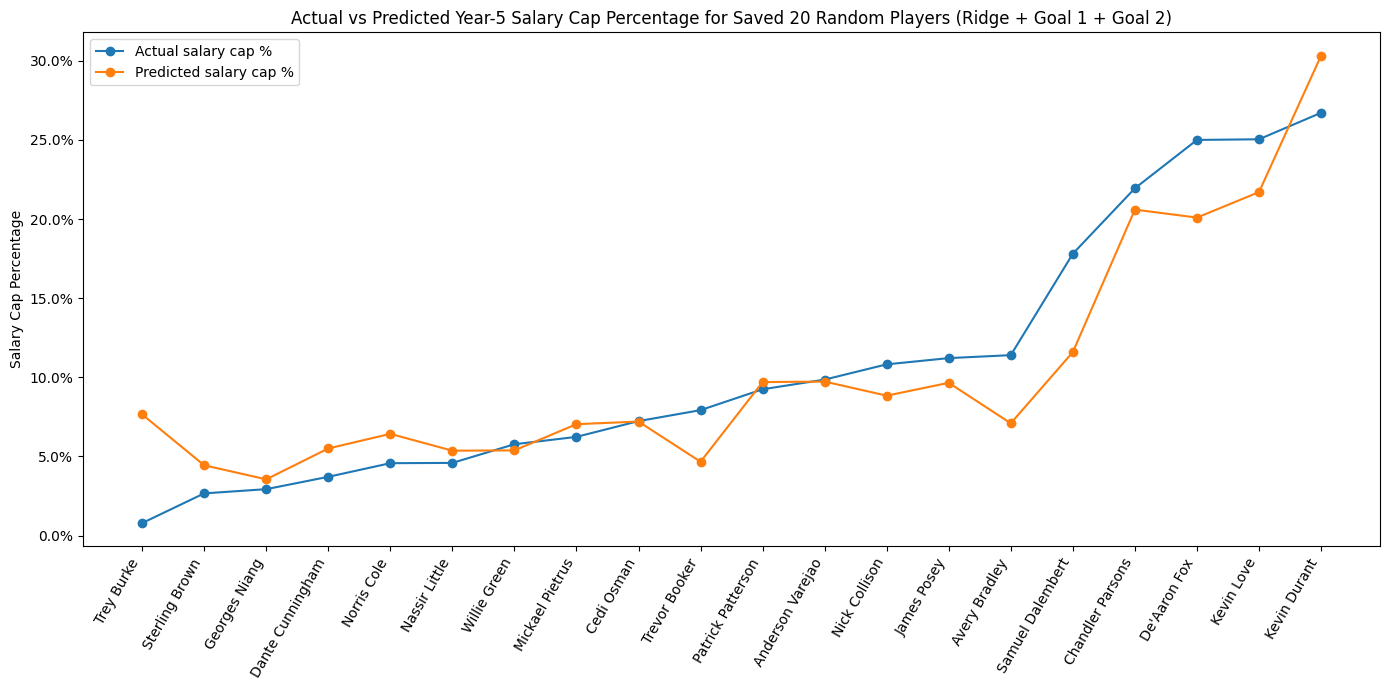

In [11]:
# --------------------------------------------------
# save 20 random players and plot
# --------------------------------------------------

sample_20_players_ridge_goal12 = cv_results_ridge_goal12.sample(n=20, random_state=750).copy()
sample_20_players_ridge_goal12 = sample_20_players_ridge_goal12.sort_values(
    "salary_cap_pct_y5"
).reset_index(drop=True)

print(sample_20_players_ridge_goal12)

plt.figure(figsize=(14, 7))

x = range(len(sample_20_players_ridge_goal12))

plt.plot(
    x,
    sample_20_players_ridge_goal12["salary_cap_pct_y5"],
    marker="o",
    label="Actual salary cap %"
)

plt.plot(
    x,
    sample_20_players_ridge_goal12["pred_salary_cap_pct_y5"],
    marker="o",
    label="Predicted salary cap %"
)

plt.xticks(
    x,
    sample_20_players_ridge_goal12["player_name_fixed"],
    rotation=60,
    ha="right"
)

plt.ylabel("Salary Cap Percentage")
plt.title("Actual vs Predicted Year-5 Salary Cap Percentage for Saved 20 Random Players (Ridge + Goal 1 + Goal 2)")
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.legend()
plt.tight_layout()
plt.show()

# Elastic Network + K-Fold Cross-Validation

In this section, we use **elastic network regression** as a second regularized predictive model to predict the **fifth-year wage cap percentage**.

## Objective

The objective of this step is to compare the elastic network with ridge regression and examine whether different types of regularization can improve the performance of wage prediction.

The advantages of the elastic network are:

- Narrowing the range of relevant predictor variables

- Reducing overfitting

- Potentially setting weaker coefficients closer to zero

- Creating a more selective model than ridge regression

Therefore, the elastic network is particularly useful when we believe that some variables may have different values ​​for prediction compared to ridge regression.

## We again use **K-fold cross-validation** to avoid the model evaluation relying too heavily on a particular data partition.

K-fold cross-validation is particularly important for the elastic network because the model has tuning parameters related to the strength and structure of regularization. Cross-validation helps us choose these settings using out-of-fold performance rather than in-sample fit.

## Model 1 contain following features:

"w_pct", "performance_score", "salary_cap_pct", "gp" and feature from goal_1. (including the predict calss and probabily for each calss)

In [12]:
# --------------------------------------------------
# Model 2: Elastic Net + Goal 1
# build model table
# --------------------------------------------------

# 1. year-varying continuous features only
candidate_features = [
    "w_pct",
    "performance_score",
    "salary_cap_pct",
    "gp"
]

feature_cols = [c for c in candidate_features if c in df_x4.columns]
print("Year-varying features used:", feature_cols)

# 2. pivot year-varying features to _y1 ... _y4
id_cols = ["player_name_fixed"]

X_wide = df_x4.pivot_table(
    index=id_cols,
    columns="season_num",
    values=feature_cols,
    aggfunc="first"
)

X_wide.columns = [f"{feat}_y{yr}" for feat, yr in X_wide.columns]
X_wide = X_wide.reset_index()

print(X_wide.head())

# 3. build age_group from year 4 age
age_y4 = (
    df_x4[df_x4["season_num"] == 4][["player_name_fixed", "age"]]
    .drop_duplicates(subset=["player_name_fixed"])
    .copy()
)

age_y4["age_group"] = pd.cut(
    age_y4["age"],
    bins=[-float("inf"), 20, 22, 24, float("inf")],
    labels=["age_le_20", "age_21_22", "age_23_24", "age_25_plus"]
)

# 4. Goal 1 player-level features
goal1_cols = [
    "player_name_fixed",
    "predicted_class",
    "prob_bust",
    "prob_neutral",
    "prob_sleeper",
    "lstm_confidence"
]

goal1_cols = [c for c in goal1_cols if c in df_x4.columns]

goal1_player = (
    df_x4[goal1_cols]
    .drop_duplicates(subset=["player_name_fixed"])
    .copy()
)

goal1_player = goal1_player.merge(
    age_y4[["player_name_fixed", "age_group"]],
    on="player_name_fixed",
    how="left"
)

print(goal1_player.head())
print("Unique players in goal1_player:", goal1_player["player_name_fixed"].nunique())

# 5. merge X_wide + Goal 1 + y
model_df_enet_goal1 = (
    X_wide
    .merge(goal1_player, on="player_name_fixed", how="inner")
    .merge(y_df, on="player_name_fixed", how="inner")
)

print("Model dataframe shape:", model_df_enet_goal1.shape)
print(model_df_enet_goal1.head())

# --------------------------------------------------
# encode categorical features and clean
# --------------------------------------------------

# categorical variables
model_df_enet_goal1 = pd.get_dummies(
    model_df_enet_goal1,
    columns=[
        "predicted_class",
        "lstm_confidence",
        "age_group"
    ],
    drop_first=False
)

print(model_df_enet_goal1.columns.tolist())

exclude_cols = ["player_name_fixed", "target_year", "salary", "salary_cap", "salary_cap_pct_y5"]
X_cols_enet_goal1 = [c for c in model_df_enet_goal1.columns if c not in exclude_cols]

for c in X_cols_enet_goal1:
    if model_df_enet_goal1[c].dtype == "bool":
        model_df_enet_goal1[c] = model_df_enet_goal1[c].astype(int)
    else:
        model_df_enet_goal1[c] = pd.to_numeric(model_df_enet_goal1[c], errors="coerce")

model_df_enet_goal1["salary_cap_pct_y5"] = pd.to_numeric(
    model_df_enet_goal1["salary_cap_pct_y5"], errors="coerce"
)

model_df_enet_goal1_clean = model_df_enet_goal1.dropna(
    subset=X_cols_enet_goal1 + ["salary_cap_pct_y5"]
).copy()

print("Clean model dataframe shape:", model_df_enet_goal1_clean.shape)

# --------------------------------------------------
# Elastic Net with 5-fold CV
# --------------------------------------------------
X_enet_goal1 = model_df_enet_goal1_clean[X_cols_enet_goal1].copy()
y_enet_goal1 = model_df_enet_goal1_clean["salary_cap_pct_y5"].copy()

pipe_enet_goal1 = Pipeline([
    ("scaler", StandardScaler()),
    ("enet", ElasticNet(max_iter=10000))
])

param_grid_enet_goal1 = {
    "enet__alpha": np.logspace(-4, 1, 30),
    "enet__l1_ratio": np.linspace(0.1, 0.9, 9)
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_enet_goal1 = GridSearchCV(
    estimator=pipe_enet_goal1,
    param_grid=param_grid_enet_goal1,
    cv=kf,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_enet_goal1.fit(X_enet_goal1, y_enet_goal1)

best_enet_goal1_model = grid_enet_goal1.best_estimator_

y_pred_cv_enet_goal1 = cross_val_predict(
    best_enet_goal1_model,
    X_enet_goal1,
    y_enet_goal1,
    cv=kf,
    n_jobs=-1
)

mse_enet_goal1 = mean_squared_error(y_enet_goal1, y_pred_cv_enet_goal1)
rmse_enet_goal1 = np.sqrt(mse_enet_goal1)
mae_enet_goal1 = mean_absolute_error(y_enet_goal1, y_pred_cv_enet_goal1)
r2_enet_goal1 = r2_score(y_enet_goal1, y_pred_cv_enet_goal1)

print("Best alpha:", grid_enet_goal1.best_params_["enet__alpha"])
print("Best l1_ratio:", grid_enet_goal1.best_params_["enet__l1_ratio"])
print("RMSE:", rmse_enet_goal1)
print("MAE:", mae_enet_goal1)
print("R^2:", r2_enet_goal1)

# --------------------------------------------------
# save CV results
# --------------------------------------------------

cv_results_enet_goal1 = model_df_enet_goal1_clean[
    ["player_name_fixed", "target_year", "salary_cap_pct_y5"]
].copy()

cv_results_enet_goal1["pred_salary_cap_pct_y5"] = y_pred_cv_enet_goal1
cv_results_enet_goal1["error"] = (
    cv_results_enet_goal1["pred_salary_cap_pct_y5"] - cv_results_enet_goal1["salary_cap_pct_y5"]
)
cv_results_enet_goal1["abs_error"] = cv_results_enet_goal1["error"].abs()

print(cv_results_enet_goal1.head(20))


Year-varying features used: ['w_pct', 'performance_score', 'salary_cap_pct', 'gp']
  player_name_fixed  gp_y1  gp_y2  gp_y3  gp_y4  performance_score_y1  \
0          AJ Price     56     50     44     57                 276.5   
1      Aaron Brooks     51     80     82     59                 168.7   
2      Aaron Gordon     47     78     80     58                 185.2   
3        Aaron Gray     61     56     32     41                 178.7   
4     Aaron Holiday     50     66     66     63                 193.7   

   performance_score_y2  performance_score_y3  performance_score_y4  \
0                 191.8                 132.1                 338.7   
1                 555.8                1038.2                 390.3   
2                 671.3                 754.4                 745.5   
3                 165.9                 102.5                 110.4   
4                 464.2                 302.1                 318.0   

   salary_cap_pct_y1  salary_cap_pct_y2  salary_cap

    player_name_fixed  target_year  salary_cap_pct_y5  pred_salary_cap_pct_y5  \
0          Trey Burke         2017           0.007913                0.069220   
1      Sterling Brown         2021           0.026687                0.046138   
2       Georges Niang         2021           0.029356                0.046281   
3    Dante Cunningham         2013           0.037151                0.056034   
4         Norris Cole         2015           0.045768                0.063228   
5       Nassir Little         2023           0.045949                0.057290   
6        Willie Green         2008           0.057737                0.063811   
7     Mickael Pietrus         2007           0.062390                0.069782   
8          Cedi Osman         2021           0.072352                0.065015   
9       Trevor Booker         2014           0.079283                0.045313   
10  Patrick Patterson         2014           0.092465                0.095762   
11   Anderson Varejao       

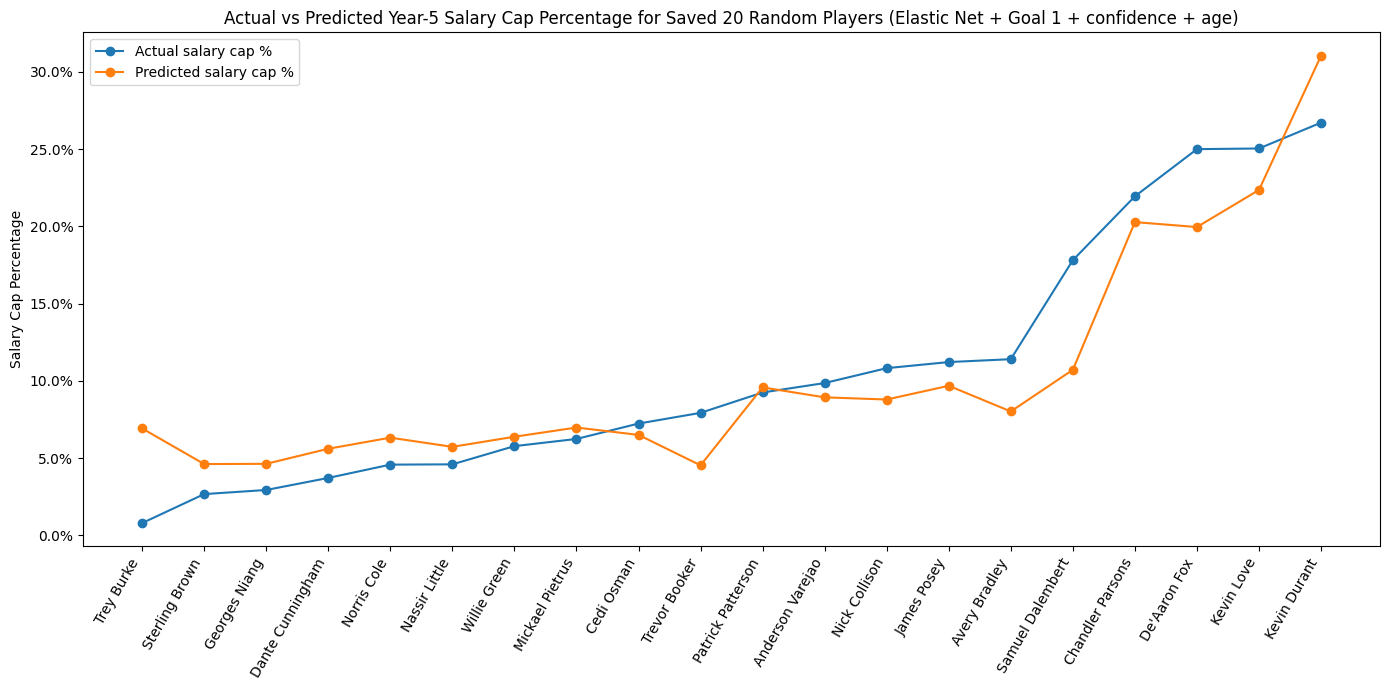

In [13]:
# --------------------------------------------------
# save 20 random players and plot
# --------------------------------------------------
sample_20_players_enet_goal1 = cv_results_enet_goal1.sample(n=20, random_state=750).copy()
sample_20_players_enet_goal1 = sample_20_players_enet_goal1.sort_values(
    "salary_cap_pct_y5"
).reset_index(drop=True)

print(sample_20_players_enet_goal1)

plt.figure(figsize=(14, 7))

x = range(len(sample_20_players_enet_goal1))

plt.plot(
    x,
    sample_20_players_enet_goal1["salary_cap_pct_y5"],
    marker="o",
    label="Actual salary cap %"
)

plt.plot(
    x,
    sample_20_players_enet_goal1["pred_salary_cap_pct_y5"],
    marker="o",
    label="Predicted salary cap %"
)

plt.xticks(
    x,
    sample_20_players_enet_goal1["player_name_fixed"],
    rotation=60,
    ha="right"
)

plt.ylabel("Salary Cap Percentage")
plt.title("Actual vs Predicted Year-5 Salary Cap Percentage for Saved 20 Random Players (Elastic Net + Goal 1 + confidence + age)")
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.legend()
plt.tight_layout()
plt.show()

## Model 2 contain following features:

"w_pct", "performance_score", "salary_cap_pct", "gp" and feature from goal_1 (including the predict calss and probabily for each calss), feature from Goal2,  includes:    "prototype_fit_ambiguity", "macro_archetype", "shot_style_subtype"

In [14]:
# --------------------------------------------------
# Model 3: Elastic Net + Goal 1 + Goal 2
# build model table
# --------------------------------------------------

# 1. year-varying continuous features only
candidate_features = [
    "w_pct",
    "performance_score",
    "salary_cap_pct",
    "gp"
]

feature_cols = [c for c in candidate_features if c in df_x4.columns]
print("Year-varying features used:", feature_cols)

# 2. pivot year-varying features to _y1 ... _y4
id_cols = ["player_name_fixed"]

X_wide = df_x4.pivot_table(
    index=id_cols,
    columns="season_num",
    values=feature_cols,
    aggfunc="first"
)

X_wide.columns = [f"{feat}_y{yr}" for feat, yr in X_wide.columns]
X_wide = X_wide.reset_index()

print(X_wide.head())

# 3. build age_group from year 4 age
age_y4 = (
    df_x4[df_x4["season_num"] == 4][["player_name_fixed", "age"]]
    .drop_duplicates(subset=["player_name_fixed"])
    .copy()
)

age_y4["age_group"] = pd.cut(
    age_y4["age"],
    bins=[-float("inf"), 20, 22, 24, float("inf")],
    labels=["age_le_20", "age_21_22", "age_23_24", "age_25_plus"]
)

# 4. Goal 1 + Goal 2 player-level features
player_level_cols = [
    "player_name_fixed",
    "predicted_class",
    "prob_bust",
    "prob_neutral",
    "prob_sleeper",
    "lstm_confidence",
    "macro_archetype",
    "shot_style_subtype",
    "prototype_fit_ambiguity"
    # "realistic_comp_similarity_mean"
]

player_level_cols = [c for c in player_level_cols if c in df_x4.columns]

player_level_df = (
    df_x4[player_level_cols]
    .drop_duplicates(subset=["player_name_fixed"])
    .copy()
)

player_level_df = player_level_df.merge(
    age_y4[["player_name_fixed", "age_group"]],
    on="player_name_fixed",
    how="left"
)

print(player_level_df.head())
print("Unique players in player_level_df:", player_level_df["player_name_fixed"].nunique())

# 5. merge X_wide + player-level features + y
model_df_enet_goal12 = (
    X_wide
    .merge(player_level_df, on="player_name_fixed", how="inner")
    .merge(y_df, on="player_name_fixed", how="inner")
)

print("Model dataframe shape:", model_df_enet_goal12.shape)
print(model_df_enet_goal12.head())

# --------------------------------------------------
# encode categorical features and clean
# --------------------------------------------------

model_df_enet_goal12 = pd.get_dummies(
    model_df_enet_goal12,
    columns=[
        "predicted_class",
        "lstm_confidence",
        "age_group",
        "macro_archetype",
        "shot_style_subtype"
    ],
    drop_first=False
)

print(model_df_enet_goal12.columns.tolist())

exclude_cols = ["player_name_fixed", "target_year", "salary", "salary_cap", "salary_cap_pct_y5"]
X_cols_enet_goal12 = [c for c in model_df_enet_goal12.columns if c not in exclude_cols]

for c in X_cols_enet_goal12:
    if model_df_enet_goal12[c].dtype == "bool":
        model_df_enet_goal12[c] = model_df_enet_goal12[c].astype(int)
    else:
        model_df_enet_goal12[c] = pd.to_numeric(model_df_enet_goal12[c], errors="coerce")

model_df_enet_goal12["salary_cap_pct_y5"] = pd.to_numeric(
    model_df_enet_goal12["salary_cap_pct_y5"], errors="coerce"
)

model_df_enet_goal12_clean = model_df_enet_goal12.dropna(
    subset=X_cols_enet_goal12 + ["salary_cap_pct_y5"]
).copy()

print("Clean model dataframe shape:", model_df_enet_goal12_clean.shape)

# --------------------------------------------------
# Elastic Net with 5-fold CV
# --------------------------------------------------
X_enet_goal12 = model_df_enet_goal12_clean[X_cols_enet_goal12].copy()
y_enet_goal12 = model_df_enet_goal12_clean["salary_cap_pct_y5"].copy()

pipe_enet_goal12 = Pipeline([
    ("scaler", StandardScaler()),
    ("enet", ElasticNet(max_iter=10000))
])

param_grid_enet_goal12 = {
    "enet__alpha": np.logspace(-4, 1, 30),
    "enet__l1_ratio": np.linspace(0.1, 0.9, 9)
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_enet_goal12 = GridSearchCV(
    estimator=pipe_enet_goal12,
    param_grid=param_grid_enet_goal12,
    cv=kf,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_enet_goal12.fit(X_enet_goal12, y_enet_goal12)

best_enet_goal12_model = grid_enet_goal12.best_estimator_

y_pred_cv_enet_goal12 = cross_val_predict(
    best_enet_goal12_model,
    X_enet_goal12,
    y_enet_goal12,
    cv=kf,
    n_jobs=-1
)

mse_enet_goal12 = mean_squared_error(y_enet_goal12, y_pred_cv_enet_goal12)
rmse_enet_goal12 = np.sqrt(mse_enet_goal12)
mae_enet_goal12 = mean_absolute_error(y_enet_goal12, y_pred_cv_enet_goal12)
r2_enet_goal12 = r2_score(y_enet_goal12, y_pred_cv_enet_goal12)

print("Best alpha:", grid_enet_goal12.best_params_["enet__alpha"])
print("Best l1_ratio:", grid_enet_goal12.best_params_["enet__l1_ratio"])
print("RMSE:", rmse_enet_goal12)
print("MAE:", mae_enet_goal12)
print("R^2:", r2_enet_goal12)

# --------------------------------------------------
# save CV results
# --------------------------------------------------

cv_results_enet_goal12 = model_df_enet_goal12_clean[
    ["player_name_fixed", "target_year", "salary_cap_pct_y5"]
].copy()

cv_results_enet_goal12["pred_salary_cap_pct_y5"] = y_pred_cv_enet_goal12
cv_results_enet_goal12["error"] = (
    cv_results_enet_goal12["pred_salary_cap_pct_y5"] - cv_results_enet_goal12["salary_cap_pct_y5"]
)
cv_results_enet_goal12["abs_error"] = cv_results_enet_goal12["error"].abs()

print(cv_results_enet_goal12.head(20))

Year-varying features used: ['w_pct', 'performance_score', 'salary_cap_pct', 'gp']
  player_name_fixed  gp_y1  gp_y2  gp_y3  gp_y4  performance_score_y1  \
0          AJ Price     56     50     44     57                 276.5   
1      Aaron Brooks     51     80     82     59                 168.7   
2      Aaron Gordon     47     78     80     58                 185.2   
3        Aaron Gray     61     56     32     41                 178.7   
4     Aaron Holiday     50     66     66     63                 193.7   

   performance_score_y2  performance_score_y3  performance_score_y4  \
0                 191.8                 132.1                 338.7   
1                 555.8                1038.2                 390.3   
2                 671.3                 754.4                 745.5   
3                 165.9                 102.5                 110.4   
4                 464.2                 302.1                 318.0   

   salary_cap_pct_y1  salary_cap_pct_y2  salary_cap

    player_name_fixed  target_year  salary_cap_pct_y5  pred_salary_cap_pct_y5  \
0          Trey Burke         2017           0.007913                0.072249   
1      Sterling Brown         2021           0.026687                0.042788   
2       Georges Niang         2021           0.029356                0.040047   
3    Dante Cunningham         2013           0.037151                0.058285   
4         Norris Cole         2015           0.045768                0.063957   
5       Nassir Little         2023           0.045949                0.050548   
6        Willie Green         2008           0.057737                0.059349   
7     Mickael Pietrus         2007           0.062390                0.070050   
8          Cedi Osman         2021           0.072352                0.069653   
9       Trevor Booker         2014           0.079283                0.051307   
10  Patrick Patterson         2014           0.092465                0.095316   
11   Anderson Varejao       

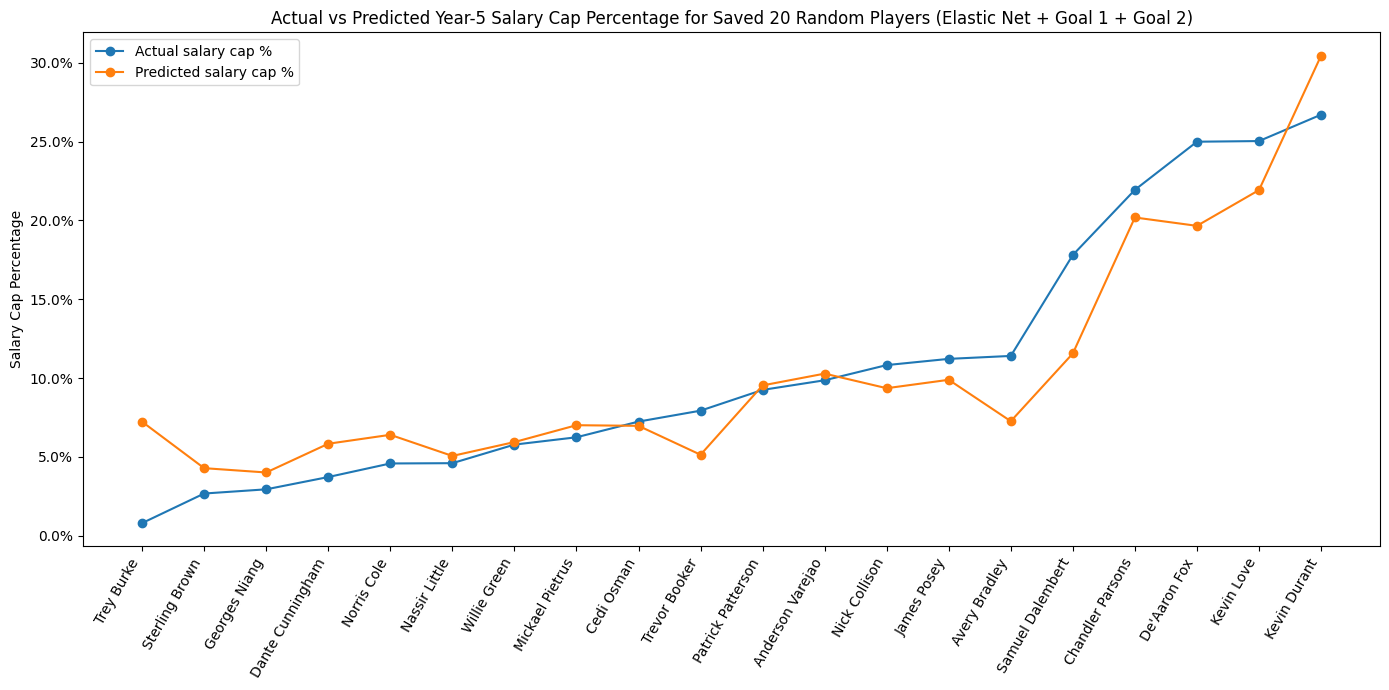

In [15]:
# --------------------------------------------------
# save 20 random players and plot
# --------------------------------------------------
sample_20_players_enet_goal12 = cv_results_enet_goal12.sample(n=20, random_state=750).copy()
sample_20_players_enet_goal12 = sample_20_players_enet_goal12.sort_values(
    "salary_cap_pct_y5"
).reset_index(drop=True)

print(sample_20_players_enet_goal12)

plt.figure(figsize=(14, 7))

x = range(len(sample_20_players_enet_goal12))

plt.plot(
    x,
    sample_20_players_enet_goal12["salary_cap_pct_y5"],
    marker="o",
    label="Actual salary cap %"
)

plt.plot(
    x,
    sample_20_players_enet_goal12["pred_salary_cap_pct_y5"],
    marker="o",
    label="Predicted salary cap %"
)

plt.xticks(
    x,
    sample_20_players_enet_goal12["player_name_fixed"],
    rotation=60,
    ha="right"
)

plt.ylabel("Salary Cap Percentage")
plt.title("Actual vs Predicted Year-5 Salary Cap Percentage for Saved 20 Random Players (Elastic Net + Goal 1 + Goal 2)")
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.legend()
plt.tight_layout()
plt.show()

# Combine the plot

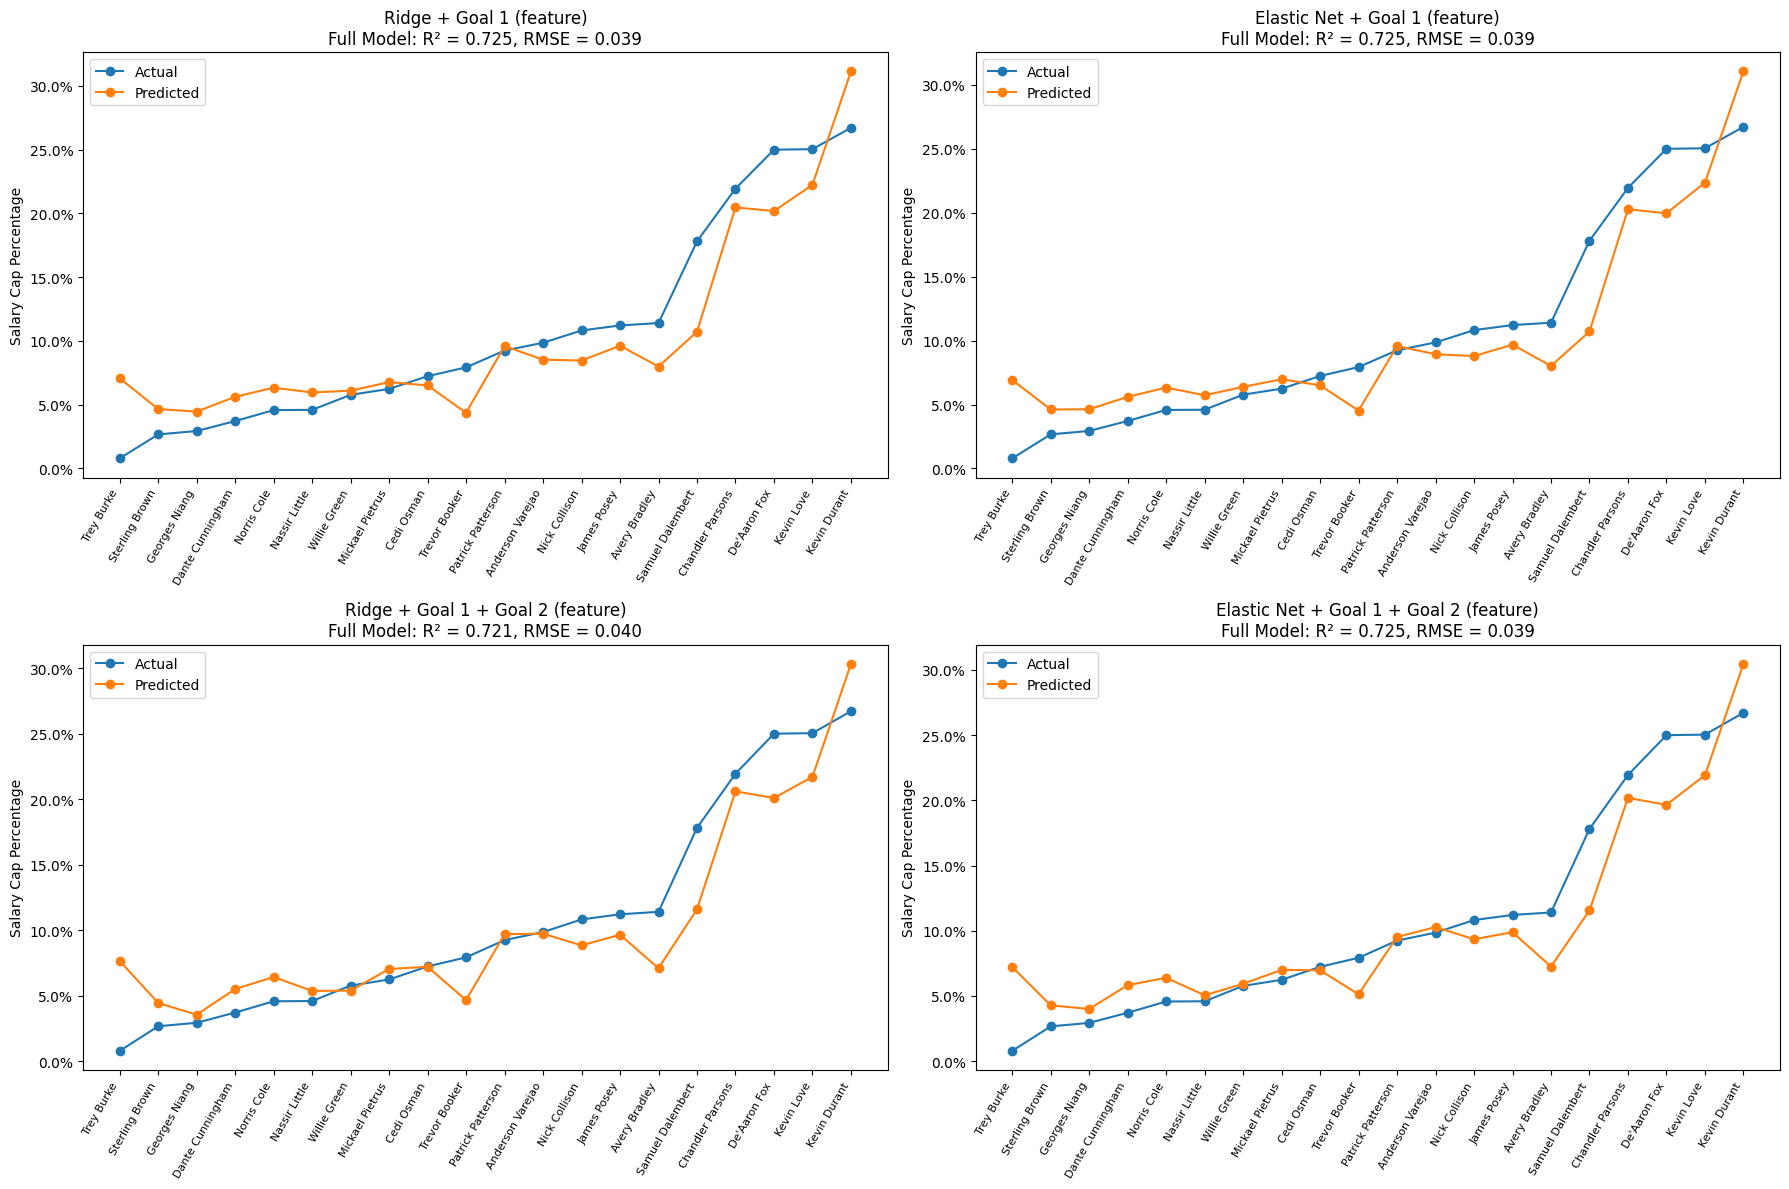

In [16]:
# ----------------------------------------
# 1. plot data + full-model result tables
# ----------------------------------------
plot_data = [
    ("Ridge + Goal 1 (feature)", sample_20_players_ridge_goal1, cv_results_ridge_goal1),
    ("Elastic Net + Goal 1 (feature)", sample_20_players_enet_goal1, cv_results_enet_goal1),
    ("Ridge + Goal 1 + Goal 2 (feature)", sample_20_players_ridge_goal12, cv_results_ridge_goal12),
    ("Elastic Net + Goal 1 + Goal 2 (feature)", sample_20_players_enet_goal12, cv_results_enet_goal12),
]

# ----------------------------------------
# 2. make 4 subplots
# ----------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for ax, (title, df_plot, df_full) in zip(axes, plot_data):
    x = range(len(df_plot))

    # full-model metrics
    y_true_full = df_full["salary_cap_pct_y5"]
    y_pred_full = df_full["pred_salary_cap_pct_y5"]

    mse_full = mean_squared_error(y_true_full, y_pred_full)
    rmse_full = np.sqrt(mse_full)
    r2_full = r2_score(y_true_full, y_pred_full)

    # sample plot
    ax.plot(
        x,
        df_plot["salary_cap_pct_y5"],
        marker="o",
        label="Actual"
    )

    ax.plot(
        x,
        df_plot["pred_salary_cap_pct_y5"],
        marker="o",
        label="Predicted"
    )

    ax.set_xticks(list(x))
    ax.set_xticklabels(df_plot["player_name_fixed"], rotation=60, ha="right", fontsize=8)
    ax.set_title(f"{title}\nFull Model: R² = {r2_full:.3f}, RMSE = {rmse_full:.3f}")
    ax.set_ylabel("Salary Cap Percentage")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.legend()

plt.tight_layout()
plt.show()

## Large-Error Group Analysis

In this part of the notebook, we move from overall model performance to subgroup-level error analysis.

First, we summarize the main regression models using RMSE, MAE, R², and a custom accuracy rule based on whether the prediction error is within a chosen tolerance. This gives an overall comparison of Ridge and Elastic Net under different feature settings.

Next, we build player-level grouping variables such as age group, predicted class, LSTM confidence, macro archetype, and shot style subtype. These variables are then merged into the player-level regression outputs so we can study where large forecasting errors are more common.

We define a large error as `|error| >= 0.03` and compute group-level large-error rates. To avoid overemphasizing very small groups, we use a smoothed or bias-adjusted large-error percentage rather than only the raw rate.

We first analyze combined groups that include class, age, confidence, archetype, and shot subtype. Then we repeat the analysis without confidence so that the final groups are easier to interpret and have larger sample sizes.

Finally, we shorten the group labels and create a top-5 comparison plot, showing the player profiles with the highest bias-adjusted large-error percentage for both Ridge and Elastic Net.

In [17]:
# --------------------------------------------------
# 1. set custom accuracy tolerance
#    example: 0.05 means within 5 percentage points of cap
# --------------------------------------------------
tolerance = 0.03

# --------------------------------------------------
# 2. helper function
# --------------------------------------------------
def get_regression_metrics(df_result, actual_col="salary_cap_pct_y5", pred_col="pred_salary_cap_pct_y5", tol=0.02):
    y_true = df_result[actual_col]
    y_pred = df_result[pred_col]

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    # custom regression "accuracy"
    acc = (np.abs(y_pred - y_true) <= tol).mean()

    return {
        "n_players": len(df_result),
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        f"Accuracy(|error|<={tol})": acc
    }

# --------------------------------------------------
# 3. compute metrics for all 6 models
# --------------------------------------------------
model_summary = pd.DataFrame({
    "Ridge + Goal 1": get_regression_metrics(cv_results_ridge_goal1, tol=tolerance),
    "Elastic Net + Goal 1": get_regression_metrics(cv_results_enet_goal1, tol=tolerance),
    "Ridge + Goal 1 + Goal 2": get_regression_metrics(cv_results_ridge_goal12, tol=tolerance),
    "Elastic Net + Goal 1 + Goal 2": get_regression_metrics(cv_results_enet_goal12, tol=tolerance),
}).T

print(model_summary)

                               n_players      RMSE       MAE        R2  \
Ridge + Goal 1                     560.0  0.039244  0.031157  0.725086   
Elastic Net + Goal 1               560.0  0.039245  0.031103  0.725073   
Ridge + Goal 1 + Goal 2            560.0  0.039516  0.031174  0.721272   
Elastic Net + Goal 1 + Goal 2      560.0  0.039243  0.030820  0.725100   

                               Accuracy(|error|<=0.03)  
Ridge + Goal 1                                0.573214  
Elastic Net + Goal 1                          0.562500  
Ridge + Goal 1 + Goal 2                       0.583929  
Elastic Net + Goal 1 + Goal 2                 0.578571  


In [18]:
# ----------------------------------------
# settings
# ----------------------------------------
threshold = 0.03
min_group_size = 5
alpha = 10   # smoothing strength

# ----------------------------------------
# 1. build age_group from year 4 age
# ----------------------------------------
age_y4 = (
    df_x4[df_x4["season_num"] == 4][["player_name_fixed", "age"]]
    .drop_duplicates(subset=["player_name_fixed"])
    .copy()
)

age_y4["age_group"] = pd.cut(
    age_y4["age"],
    bins=[-float("inf"), 20, 22, 24, float("inf")],
    labels=["age_le_20", "age_21_22", "age_23_24", "age_25_plus"]
)

# ----------------------------------------
# 2. build one player-level label table
# ----------------------------------------
label_cols = [
    "player_name_fixed",
    "predicted_class",
    "lstm_confidence",
    "macro_archetype",
    "shot_style_subtype"
]

label_cols = [c for c in label_cols if c in df_x4.columns]

player_labels = (
    df_x4[label_cols]
    .drop_duplicates(subset=["player_name_fixed"])
    .copy()
)

player_labels = player_labels.merge(
    age_y4[["player_name_fixed", "age_group"]],
    on="player_name_fixed",
    how="left"
)

In [19]:
# ----------------------------------------
# 3. merge labels into model results
# ----------------------------------------
ridge_full = cv_results_ridge_goal12.merge(
    player_labels,
    on="player_name_fixed",
    how="left"
).copy()

enet_full = cv_results_enet_goal12.merge(
    player_labels,
    on="player_name_fixed",
    how="left"
).copy()

# ----------------------------------------
# 4. drop rows with missing group fields
# ----------------------------------------
group_fields = [
    "predicted_class",
    "age_group",
    "lstm_confidence",
    "macro_archetype",
    "shot_style_subtype"
]

ridge_full = ridge_full.dropna(subset=group_fields).copy()
enet_full = enet_full.dropna(subset=group_fields).copy()

# ----------------------------------------
# 5. define large error
# ----------------------------------------
ridge_full["large_error_flag"] = (ridge_full["abs_error"] >= threshold).astype(int)
enet_full["large_error_flag"] = (enet_full["abs_error"] >= threshold).astype(int)

# ----------------------------------------
# 6. combined group label
# ----------------------------------------
ridge_full["combined_group"] = (
    ridge_full["predicted_class"].astype(str) + " | " +
    ridge_full["age_group"].astype(str) + " | " +
    ridge_full["lstm_confidence"].astype(str) + " | " +
    ridge_full["macro_archetype"].astype(str) + " | " +
    ridge_full["shot_style_subtype"].astype(str)
)

enet_full["combined_group"] = (
    enet_full["predicted_class"].astype(str) + " | " +
    enet_full["age_group"].astype(str) + " | " +
    enet_full["lstm_confidence"].astype(str) + " | " +
    enet_full["macro_archetype"].astype(str) + " | " +
    enet_full["shot_style_subtype"].astype(str)
)

# ----------------------------------------
# 7. fair summary function
# ----------------------------------------
def fair_group_summary(df, model_name, min_n=5, alpha=10):
    overall_rate = df["large_error_flag"].mean()

    out = (
        df.groupby("combined_group")
        .agg(
            group_size=("player_name_fixed", "nunique"),
            large_error_count=("large_error_flag", "sum")
        )
        .reset_index()
    )

    out = out[out["group_size"] >= min_n].copy()

    out["raw_error_rate"] = out["large_error_count"] / out["group_size"]

    # smoothed rate to reduce tiny-group bias
    out["smoothed_error_rate"] = (
        out["large_error_count"] + alpha * overall_rate
    ) / (
        out["group_size"] + alpha
    )

    out["raw_error_pct"] = out["raw_error_rate"] * 100
    out["smoothed_error_pct"] = out["smoothed_error_rate"] * 100
    out["model"] = model_name
    out["overall_error_pct"] = overall_rate * 100

    return out.sort_values("smoothed_error_pct", ascending=False)

ridge_fair = fair_group_summary(ridge_full, "Ridge", min_n=min_group_size, alpha=alpha)
enet_fair  = fair_group_summary(enet_full, "Elastic Net", min_n=min_group_size, alpha=alpha)

# print("Top Ridge groups:")
# display(ridge_fair.head(10))

# print("Top Elastic Net groups:")
# display(enet_fair.head(10))

# ----------------------------------------
# 8. combine both models and find top 5 groups
#    using average smoothed error percentage
# ----------------------------------------
combo_fair = ridge_fair.merge(
    enet_fair,
    on="combined_group",
    how="outer",
    suffixes=("_ridge", "_enet")
)

fill_cols = [
    "group_size_ridge", "large_error_count_ridge", "raw_error_rate_ridge", "smoothed_error_rate_ridge",
    "raw_error_pct_ridge", "smoothed_error_pct_ridge",
    "group_size_enet", "large_error_count_enet", "raw_error_rate_enet", "smoothed_error_rate_enet",
    "raw_error_pct_enet", "smoothed_error_pct_enet"
]

for col in fill_cols:
    if col in combo_fair.columns:
        combo_fair[col] = combo_fair[col].fillna(0)

combo_fair["avg_smoothed_error_pct"] = (
    combo_fair["smoothed_error_pct_ridge"] + combo_fair["smoothed_error_pct_enet"]
) / 2

top5_groups = combo_fair.sort_values("avg_smoothed_error_pct", ascending=False).head(5).copy()

print("Top 5 combined groups with highest bias-adjusted large-error percentage:")
print(
    top5_groups[
        [
            "combined_group",
            "group_size_ridge", "large_error_count_ridge", "smoothed_error_pct_ridge",
            "group_size_enet", "large_error_count_enet", "smoothed_error_pct_enet",
            "avg_smoothed_error_pct"
        ]
    ]
)

Top 5 combined groups with highest bias-adjusted large-error percentage:
                                       combined_group  group_size_ridge  \
11  Neutral | age_23_24 | High | High-Usage Primar...                21   
16  Neutral | age_23_24 | Medium | Scoring Bigs / ...                 6   
14  Neutral | age_23_24 | Medium | High-Usage Prim...                 7   
13  Neutral | age_23_24 | High | Scoring Bigs / Tw...                21   
26  Sleeper | age_23_24 | High | Scoring Bigs / Tw...                13   

    large_error_count_ridge  smoothed_error_pct_ridge  group_size_enet  \
11                       16                 65.019612               21   
16                        5                 57.225499                6   
14                        5                 53.859293                7   
13                       13                 55.342193               21   
26                        7                 48.504695               13   

    large_error_count_enet  smo

In [20]:
# ----------------------------------------
# settings
# ----------------------------------------
threshold = 0.03
min_group_size = 10
alpha = 10

# ----------------------------------------
# 1. build age_group from year 4 age
# ----------------------------------------
age_y4 = (
    df_x4[df_x4["season_num"] == 4][["player_name_fixed", "age"]]
    .drop_duplicates(subset=["player_name_fixed"])
    .copy()
)

age_y4["age_group"] = pd.cut(
    age_y4["age"],
    bins=[-float("inf"), 20, 22, 24, float("inf")],
    labels=["age_le_20", "age_21_22", "age_23_24", "age_25_plus"]
)

# ----------------------------------------
# 2. build one player-level label table
#    WITHOUT lstm_confidence
# ----------------------------------------
label_cols = [
    "player_name_fixed",
    "predicted_class",
    "macro_archetype",
    "shot_style_subtype"
]

label_cols = [c for c in label_cols if c in df_x4.columns]

player_labels = (
    df_x4[label_cols]
    .drop_duplicates(subset=["player_name_fixed"])
    .copy()
)

player_labels = player_labels.merge(
    age_y4[["player_name_fixed", "age_group"]],
    on="player_name_fixed",
    how="left"
)

# ----------------------------------------
# 3. merge labels into model results
# ----------------------------------------
ridge_full = cv_results_ridge_goal12.merge(
    player_labels,
    on="player_name_fixed",
    how="left"
).copy()

enet_full = cv_results_enet_goal12.merge(
    player_labels,
    on="player_name_fixed",
    how="left"
).copy()

# ----------------------------------------
# 4. drop rows with missing group fields
# ----------------------------------------
group_fields = [
    "predicted_class",
    "age_group",
    "macro_archetype",
    "shot_style_subtype"
]

ridge_full = ridge_full.dropna(subset=group_fields).copy()
enet_full = enet_full.dropna(subset=group_fields).copy()

# ----------------------------------------
# 5. define large error
# ----------------------------------------
ridge_full["large_error_flag"] = (ridge_full["abs_error"] >= threshold).astype(int)
enet_full["large_error_flag"] = (enet_full["abs_error"] >= threshold).astype(int)

# ----------------------------------------
# 6. combined group label
#    WITHOUT lstm_confidence
# ----------------------------------------
ridge_full["combined_group"] = (
    ridge_full["predicted_class"].astype(str) + " | " +
    ridge_full["age_group"].astype(str) + " | " +
    ridge_full["macro_archetype"].astype(str) + " | " +
    ridge_full["shot_style_subtype"].astype(str)
)

enet_full["combined_group"] = (
    enet_full["predicted_class"].astype(str) + " | " +
    enet_full["age_group"].astype(str) + " | " +
    enet_full["macro_archetype"].astype(str) + " | " +
    enet_full["shot_style_subtype"].astype(str)
)

# ----------------------------------------
# 7. fair summary function
# ----------------------------------------
def fair_group_summary(df, model_name, min_n=5, alpha=10):
    overall_rate = df["large_error_flag"].mean()

    out = (
        df.groupby("combined_group")
        .agg(
            group_size=("player_name_fixed", "nunique"),
            large_error_count=("large_error_flag", "sum")
        )
        .reset_index()
    )

    out = out[out["group_size"] >= min_n].copy()

    out["raw_error_rate"] = out["large_error_count"] / out["group_size"]
    out["smoothed_error_rate"] = (
        out["large_error_count"] + alpha * overall_rate
    ) / (
        out["group_size"] + alpha
    )

    out["raw_error_pct"] = out["raw_error_rate"] * 100
    out["smoothed_error_pct"] = out["smoothed_error_rate"] * 100
    out["model"] = model_name
    out["overall_error_pct"] = overall_rate * 100

    return out.sort_values("smoothed_error_pct", ascending=False)

ridge_fair = fair_group_summary(ridge_full, "Ridge", min_n=min_group_size, alpha=alpha)
enet_fair  = fair_group_summary(enet_full, "Elastic Net", min_n=min_group_size, alpha=alpha)

combo_fair = ridge_fair.merge(
    enet_fair,
    on="combined_group",
    how="outer",
    suffixes=("_ridge", "_enet")
)

fill_cols = [
    "group_size_ridge", "large_error_count_ridge", "raw_error_rate_ridge", "smoothed_error_rate_ridge",
    "raw_error_pct_ridge", "smoothed_error_pct_ridge",
    "group_size_enet", "large_error_count_enet", "raw_error_rate_enet", "smoothed_error_rate_enet",
    "raw_error_pct_enet", "smoothed_error_pct_enet"
]

for col in fill_cols:
    if col in combo_fair.columns:
        combo_fair[col] = combo_fair[col].fillna(0)

combo_fair["avg_smoothed_error_pct"] = (
    combo_fair["smoothed_error_pct_ridge"] + combo_fair["smoothed_error_pct_enet"]
) / 2

top5_groups = combo_fair.sort_values("avg_smoothed_error_pct", ascending=False).head(5).copy()

,short_label,group_size_ridge,large_error_count_ridge,smoothed_error_pct_ridge,group_size_enet,large_error_count_enet,smoothed_error_pct_enet
7,NEU | 23-24 | Primary | RimDrv,28,21,66.200210,28,21,66.391250
9,NEU | 23-24 | Scoring Bi | RimDrv,29,19,59.374564,29,17,54.432500
14,SL | 23-24 | Scoring Bi | RimDrv,14,8,50.650333,14,9,55.119480
10,NEU | 25+ | Primary | RimDrv,27,14,49.070486,27,13,46.563987
16,SL | 25+ | Scoring Bi | RimDrv,10,3,35.780399,10,6,51.143376


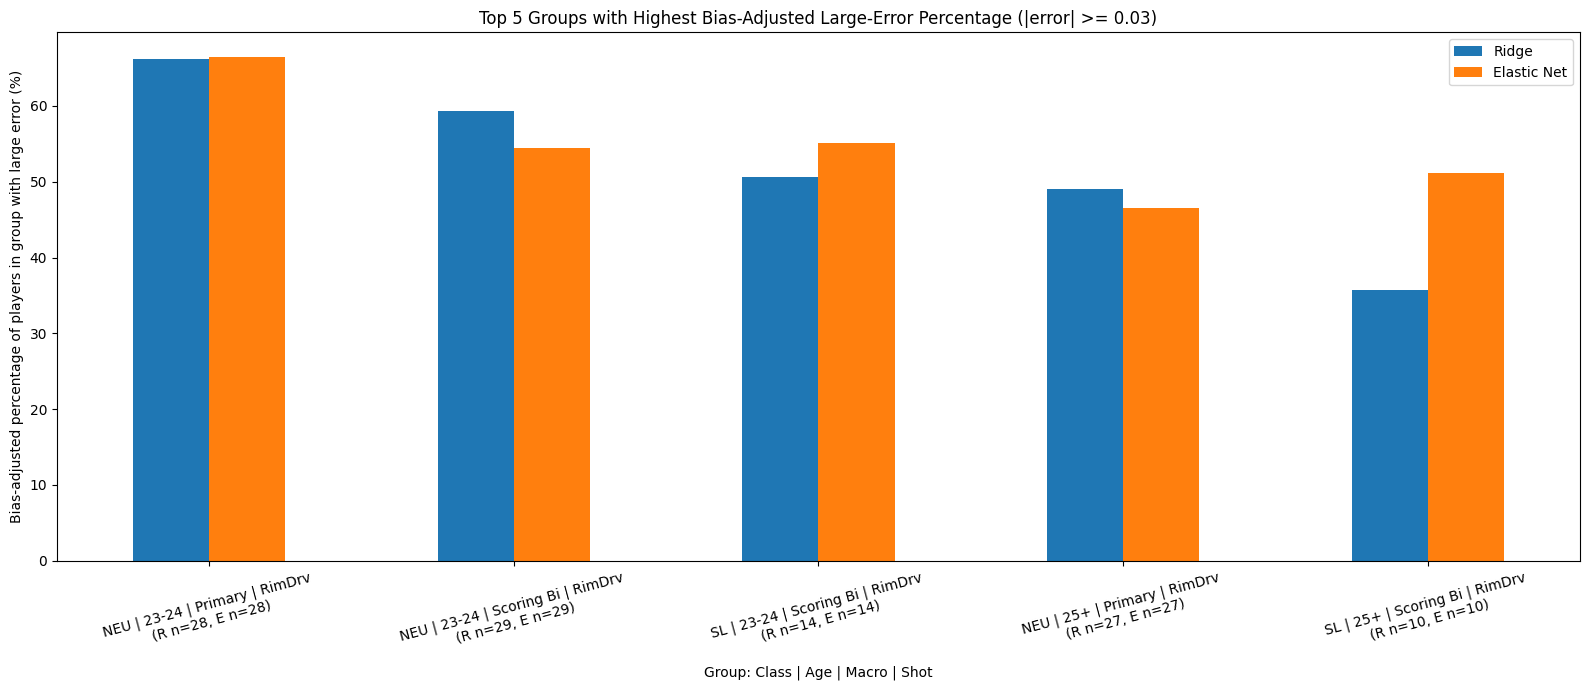

In [21]:
# short label maps
class_map = {
    "Sleeper": "SL",
    "Neutral": "NEU",
    "Bust": "BU"
}

age_map = {
    "age_le_20": "≤20",
    "age_21_22": "21-22",
    "age_23_24": "23-24",
    "age_25_plus": "25+"
}

macro_map = {
    "High Scoring Bigs": "ScoreBig",
    "High-Usage Primary Creators": "Primary",
    "Low-Usage Interior Bigs": "Interior",
    "Two-Way Forwards": "2WayFwd",
    "Rim Pressure Drivers": "RimDrv",
    "Midrange Shot Creators": "MidShot"
}

shot_map = {
    "High Scoring Bigs": "ScoreBig",
    "High-Usage Primary Creators": "Primary",
    "Low-Usage Interior Bigs": "Interior",
    "Two-Way Forwards": "2WayFwd",
    "Rim Pressure Drivers": "RimDrv",
    "Midrange Shot Creators": "MidShot"
}

def shorten_combined_label_no_conf(s):
    parts = [p.strip() for p in str(s).split("|")]
    if len(parts) != 4:
        return str(s)

    cls, age, macro, shot = parts

    cls_s = class_map.get(cls, cls[:4])
    age_s = age_map.get(age, age)
    macro_s = macro_map.get(macro, macro[:10])
    shot_s = shot_map.get(shot, shot[:10])

    return f"{cls_s} | {age_s} | {macro_s} | {shot_s}"

plot_df = top5_groups[
    [
        "combined_group",
        "group_size_ridge",
        "large_error_count_ridge",
        "smoothed_error_pct_ridge",
        "group_size_enet",
        "large_error_count_enet",
        "smoothed_error_pct_enet"
    ]
].copy()

plot_df["short_label"] = plot_df["combined_group"].apply(shorten_combined_label_no_conf)

plot_df["label"] = (
    plot_df["short_label"]
    + "\n(R n=" + plot_df["group_size_ridge"].astype(int).astype(str)
    + ", E n=" + plot_df["group_size_enet"].astype(int).astype(str) + ")"
)

# cleaner table for display
top5_group_table = plot_df[
    [
        "short_label",
        "group_size_ridge",
        "large_error_count_ridge",
        "smoothed_error_pct_ridge",
        "group_size_enet",
        "large_error_count_enet",
        "smoothed_error_pct_enet"
    ]
].copy()

display(top5_group_table)

plot_show = plot_df[
    ["label", "smoothed_error_pct_ridge", "smoothed_error_pct_enet"]
].rename(columns={
    "smoothed_error_pct_ridge": "Ridge",
    "smoothed_error_pct_enet": "Elastic Net"
}).set_index("label")

ax = plot_show.plot(
    kind="bar",
    figsize=(16, 7)
)

ax.set_title(f"Top 5 Groups with Highest Bias-Adjusted Large-Error Percentage (|error| >= {threshold:.2f})")
ax.set_xlabel("Group: Class | Age | Macro | Shot")
ax.set_ylabel("Bias-adjusted percentage of players in group with large error (%)")
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

# Conclusion

Overall, the four regression models perform very similarly. Their RMSE values are all around 0.039 to 0.040, MAE values are around 0.031, and R² values are all close to 0.725. This means the models explain a meaningful part of the variation in Year-5 salary cap percentage, but the improvement from adding more features is fairly small. Among the four models, Ridge + Goal 1 has the highest custom accuracy under the |error| <= 0.03 rule, while Elastic Net + Goal 1 is slightly weaker. Adding Goal 2 features does not create a major performance jump, so the richer feature set helps only marginally in this forecasting task.

The large-error analysis shows that model risk is not evenly distributed across all player groups. Instead, the highest-risk groups are concentrated in a few specific player profiles. The top 5 combined groups are mostly players who are:

- Neutral or sometimes Sleeper
- in the 23–24 age range or 25+
- mainly in Primary or Scoring Big role types
- strongly linked to Rim Pressure Driver style

**The highest-risk group is: Neutral | 23–24 | Primary | RimDrv**

For this group, both Ridge and Elastic Net have a very high bias-adjusted large-error percentage, around 65%. This means that for players in this profile, the models frequently miss the true Year-5 salary outcome by more than 0.03 of salary cap.

The next few risky groups also show a similar pattern. They are mostly:

- Neutral players aged 23–24
- scoring big or primary-role players
- tied to rim-pressure style

This suggests that the combination of age 23–24, high offensive responsibility, and rim-pressure role creates especially high salary uncertainty. These players may have more volatile market value because their contract outcome depends not only on past box-score production, but also on things like offensive role expansion, perceived upside, team need, and market timing.

Another important pattern is that Ridge and Elastic Net usually agree on which groups are risky. Their bars are close in most of the top-5 groups, which suggests that the uncertainty pattern comes from the data structure itself, not from one particular model choice. However, one Sleeper 25+ Scoring Big / RimDrv group shows a bigger gap, where Elastic Net has noticeably higher large-error percentage than Ridge. This means some groups may still be more sensitive to model specification.


## Final interpretation

These results support three main conclusions:

1. Ridge and Elastic Net provide stable baseline forecasts, but neither model dramatically outperforms the other.

2. Overall fit is decent but not perfect, so Year-5 salary cap percentage can be predicted to a useful extent, but there is still meaningful unexplained variation.

3. The largest forecasting risk is concentrated in specific player profiles, especially Neutral players aged 23–24 in Primary or Scoring Big roles with Rim Pressure Driver style. These groups should therefore be treated with extra caution in salary decision support.

# The following is a detailed analysis of each group category: 

In [22]:
# ----------------------------------------
# settings
# ----------------------------------------
threshold = 0.03
min_group_size = 5
alpha = 10   # smoothing strength

# ----------------------------------------
# 1. build age_group from year 4 age
# ----------------------------------------
age_y4 = (
    df_x4[df_x4["season_num"] == 4][["player_name_fixed", "age"]]
    .drop_duplicates(subset=["player_name_fixed"])
    .copy()
)

age_y4["age_group"] = pd.cut(
    age_y4["age"],
    bins=[-float("inf"), 20, 22, 24, float("inf")],
    labels=["age_le_20", "age_21_22", "age_23_24", "age_25_plus"]
)

# ----------------------------------------
# 2. one player-level label table
# ----------------------------------------
player_labels = (
    df_x4[
        [
            "player_name_fixed",
            "predicted_class",
            "macro_archetype",
            "shot_style_subtype"
        ]
    ]
    .drop_duplicates(subset=["player_name_fixed"])
    .copy()
)

player_labels = player_labels.merge(
    age_y4[["player_name_fixed", "age_group"]],
    on="player_name_fixed",
    how="left"
)

# ----------------------------------------
# 3. merge labels into both models
# ----------------------------------------
ridge_labels = cv_results_ridge_goal12.merge(
    player_labels,
    on="player_name_fixed",
    how="left"
).copy()

enet_labels = cv_results_enet_goal12.merge(
    player_labels,
    on="player_name_fixed",
    how="left"
).copy()

# ----------------------------------------
# 4. define large error
# ----------------------------------------
ridge_labels["large_error_flag"] = (ridge_labels["abs_error"] >= threshold).astype(int)
enet_labels["large_error_flag"] = (enet_labels["abs_error"] >= threshold).astype(int)

print("Ridge rows:", len(ridge_labels))
print("Elastic Net rows:", len(enet_labels))

Ridge rows: 560
Elastic Net rows: 560


In [23]:
# ----------------------------------------
# helper: fair group summary
# solves class size imbalance
# ----------------------------------------
def fair_group_summary(df, group_col, model_name, min_n=5, alpha=10):
    temp = df.dropna(subset=[group_col]).copy()

    overall_rate = temp["large_error_flag"].mean()

    out = (
        temp.groupby(group_col, observed=False)
        .agg(
            group_size=("player_name_fixed", "nunique"),
            large_error_count=("large_error_flag", "sum")
        )
        .reset_index()
    )

    # remove tiny groups
    out = out[out["group_size"] >= min_n].copy()

    # raw within-group error percentage
    out["raw_error_rate"] = out["large_error_count"] / out["group_size"]
    out["raw_error_pct"] = out["raw_error_rate"] * 100

    # smoothed within-group error percentage
    out["smoothed_error_rate"] = (
        out["large_error_count"] + alpha * overall_rate
    ) / (
        out["group_size"] + alpha
    )
    out["smoothed_error_pct"] = out["smoothed_error_rate"] * 100

    out["overall_error_pct"] = overall_rate * 100
    out["model"] = model_name

    return out.sort_values("smoothed_error_pct", ascending=False)

,age_group,group_size_ridge,large_error_count_ridge,raw_error_pct_ridge,smoothed_error_pct_ridge,group_size_enet,large_error_count_enet,raw_error_pct_enet,smoothed_error_pct_enet
0,age_21_22,26,15,57.692308,53.224206,26,17,65.384615,58.928571
1,age_23_24,214,109,50.934579,50.518176,214,108,50.467290,50.095663
2,age_25_plus,320,109,34.062500,34.291126,320,111,34.687500,34.913420


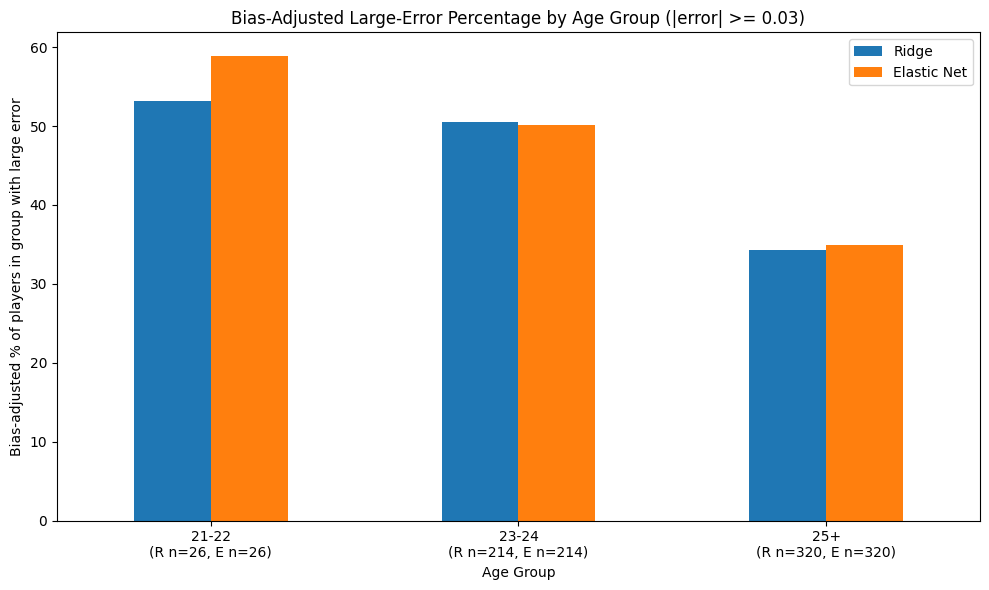

In [24]:
# ----------------------------------------
# AGE GROUP
# ----------------------------------------
ridge_age_summary = fair_group_summary(ridge_labels, "age_group", "Ridge", min_n=min_group_size, alpha=alpha)
enet_age_summary  = fair_group_summary(enet_labels, "age_group", "Elastic Net", min_n=min_group_size, alpha=alpha)

age_compare = ridge_age_summary.merge(
    enet_age_summary,
    on="age_group",
    how="outer",
    suffixes=("_ridge", "_enet")
)

display(age_compare[
    [
        "age_group",
        "group_size_ridge", "large_error_count_ridge", "raw_error_pct_ridge", "smoothed_error_pct_ridge",
        "group_size_enet", "large_error_count_enet", "raw_error_pct_enet", "smoothed_error_pct_enet"
    ]
])

age_label_map = {
    "age_le_20": "≤20",
    "age_21_22": "21-22",
    "age_23_24": "23-24",
    "age_25_plus": "25+"
}

plot_df = age_compare.copy()
plot_df["age_label"] = plot_df["age_group"].astype(str).map(age_label_map)
plot_df["label"] = (
    plot_df["age_label"]
    + "\n(R n=" + plot_df["group_size_ridge"].astype(int).astype(str)
    + ", E n=" + plot_df["group_size_enet"].astype(int).astype(str) + ")"
)

plot_show = plot_df[
    ["label", "smoothed_error_pct_ridge", "smoothed_error_pct_enet"]
].rename(columns={
    "smoothed_error_pct_ridge": "Ridge",
    "smoothed_error_pct_enet": "Elastic Net"
}).set_index("label")

ax = plot_show.plot(kind="bar", figsize=(10, 6))
ax.set_title(f"Bias-Adjusted Large-Error Percentage by Age Group (|error| >= {threshold:.2f})")
ax.set_xlabel("Age Group")
ax.set_ylabel("Bias-adjusted % of players in group with large error")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

,predicted_class,group_size_ridge,large_error_count_ridge,raw_error_pct_ridge,smoothed_error_pct_ridge,group_size_enet,large_error_count_enet,raw_error_pct_enet,smoothed_error_pct_enet
0,Bust,244,73,29.918033,30.378234,244,76,31.147541,31.580427
1,Neutral,224,119,53.125000,52.632784,224,117,52.232143,51.800977
2,Sleeper,92,41,44.565217,44.275210,92,43,46.739130,46.288515


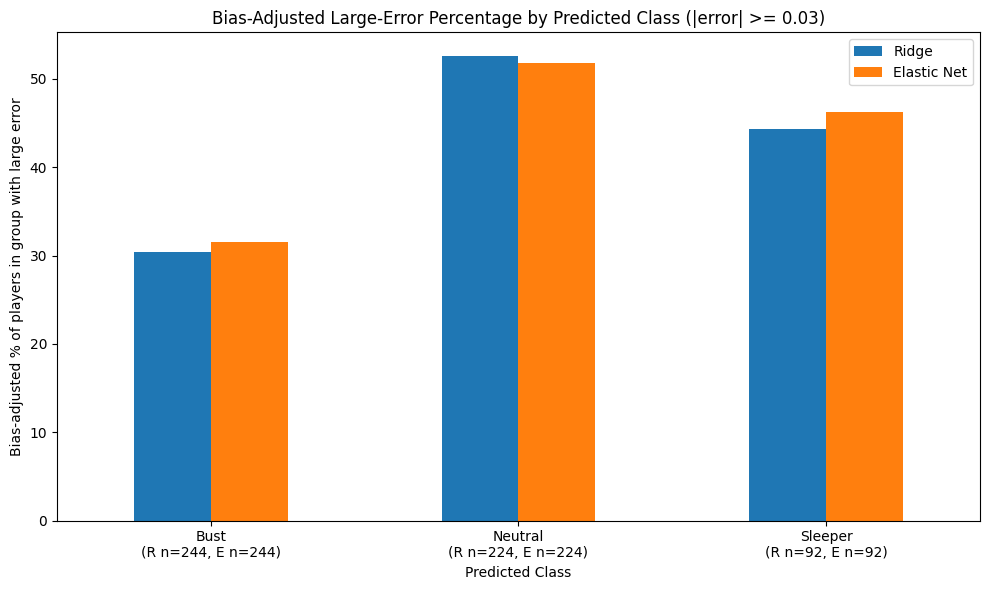

In [25]:
# ----------------------------------------
# PREDICTED CLASS
# ----------------------------------------
ridge_class_summary = fair_group_summary(ridge_labels, "predicted_class", "Ridge", min_n=min_group_size, alpha=alpha)
enet_class_summary  = fair_group_summary(enet_labels, "predicted_class", "Elastic Net", min_n=min_group_size, alpha=alpha)

class_compare = ridge_class_summary.merge(
    enet_class_summary,
    on="predicted_class",
    how="outer",
    suffixes=("_ridge", "_enet")
).fillna(0)

display(class_compare[
    [
        "predicted_class",
        "group_size_ridge", "large_error_count_ridge", "raw_error_pct_ridge", "smoothed_error_pct_ridge",
        "group_size_enet", "large_error_count_enet", "raw_error_pct_enet", "smoothed_error_pct_enet"
    ]
])

plot_df = class_compare.copy()
plot_df["label"] = (
    plot_df["predicted_class"].astype(str)
    + "\n(R n=" + plot_df["group_size_ridge"].astype(int).astype(str)
    + ", E n=" + plot_df["group_size_enet"].astype(int).astype(str) + ")"
)

plot_show = plot_df[
    ["label", "smoothed_error_pct_ridge", "smoothed_error_pct_enet"]
].rename(columns={
    "smoothed_error_pct_ridge": "Ridge",
    "smoothed_error_pct_enet": "Elastic Net"
}).set_index("label")

ax = plot_show.plot(kind="bar", figsize=(10, 6))
ax.set_title(f"Bias-Adjusted Large-Error Percentage by Predicted Class (|error| >= {threshold:.2f})")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("Bias-adjusted % of players in group with large error")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

,macro_archetype,group_size_ridge,large_error_count_ridge,raw_error_pct_ridge,smoothed_error_pct_ridge,group_size_enet,large_error_count_enet,raw_error_pct_enet,smoothed_error_pct_enet
0,Fringe / Low-Opportunity Players,7,3,42.857143,42.121849,7,3,42.857143,42.436975
1,High-Usage Primary Creators,111,62,55.855856,54.678276,111,57,51.351351,50.590319
2,Low-Usage Interior Bigs,112,41,36.607143,37.016979,112,38,33.928571,34.601874
3,Perimeter Wings & Connectors,162,48,29.629630,30.325997,162,54,33.333333,33.845515
4,Scoring Bigs / Two-Way Forwards,168,79,47.023810,46.719502,168,84,50.000000,49.558587


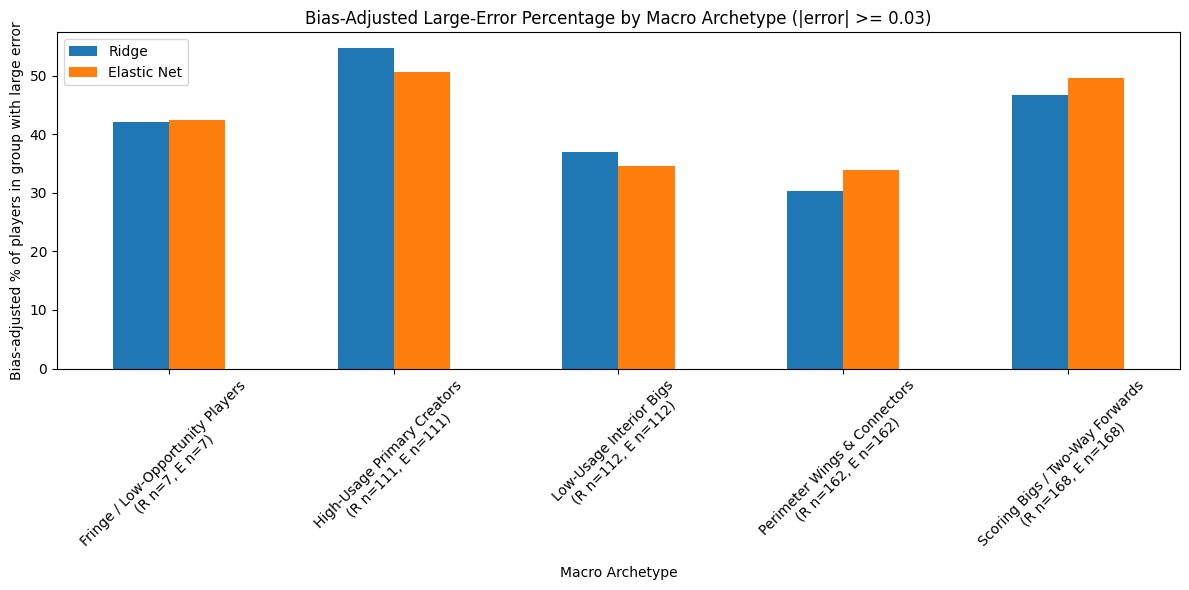

In [26]:
# ----------------------------------------
# MACRO ARCHETYPE
# ----------------------------------------
ridge_macro_summary = fair_group_summary(ridge_labels, "macro_archetype", "Ridge", min_n=min_group_size, alpha=alpha)
enet_macro_summary  = fair_group_summary(enet_labels, "macro_archetype", "Elastic Net", min_n=min_group_size, alpha=alpha)

macro_compare = ridge_macro_summary.merge(
    enet_macro_summary,
    on="macro_archetype",
    how="outer",
    suffixes=("_ridge", "_enet")
).fillna(0)

display(macro_compare[
    [
        "macro_archetype",
        "group_size_ridge", "large_error_count_ridge", "raw_error_pct_ridge", "smoothed_error_pct_ridge",
        "group_size_enet", "large_error_count_enet", "raw_error_pct_enet", "smoothed_error_pct_enet"
    ]
])

plot_df = macro_compare.copy()
plot_df["label"] = (
    plot_df["macro_archetype"].astype(str)
    + "\n(R n=" + plot_df["group_size_ridge"].astype(int).astype(str)
    + ", E n=" + plot_df["group_size_enet"].astype(int).astype(str) + ")"
)

plot_show = plot_df[
    ["label", "smoothed_error_pct_ridge", "smoothed_error_pct_enet"]
].rename(columns={
    "smoothed_error_pct_ridge": "Ridge",
    "smoothed_error_pct_enet": "Elastic Net"
}).set_index("label")

ax = plot_show.plot(kind="bar", figsize=(12, 6))
ax.set_title(f"Bias-Adjusted Large-Error Percentage by Macro Archetype (|error| >= {threshold:.2f})")
ax.set_xlabel("Macro Archetype")
ax.set_ylabel("Bias-adjusted % of players in group with large error")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

,shot_style_subtype,group_size_ridge,large_error_count_ridge,raw_error_pct_ridge,smoothed_error_pct_ridge,group_size_enet,large_error_count_enet,raw_error_pct_enet,smoothed_error_pct_enet
0,Arc-Heavy Spacers,73,28,38.356164,38.742265,73,27,36.986301,37.624910
1,Balanced Three-Level Scorers,14,5,35.714286,38.150333,14,5,35.714286,38.452813
2,Interior Finishers,36,16,44.444444,43.817565,36,15,41.666667,41.801468
3,Midrange Shot Creators,41,17,41.463415,41.482510,41,17,41.463415,41.624853
4,Rim Pressure Drivers,387,163,42.118863,42.104806,387,169,43.669251,43.634427


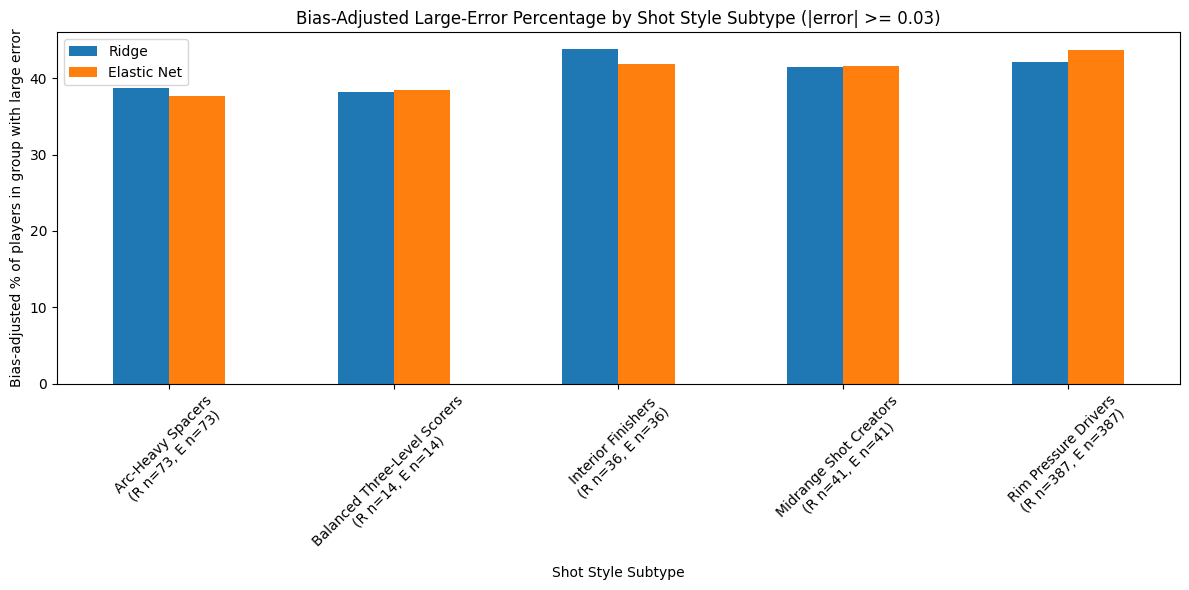

In [27]:
# ----------------------------------------
# SHOT STYLE SUBTYPE
# ----------------------------------------
ridge_shot_summary = fair_group_summary(ridge_labels, "shot_style_subtype", "Ridge", min_n=min_group_size, alpha=alpha)
enet_shot_summary  = fair_group_summary(enet_labels, "shot_style_subtype", "Elastic Net", min_n=min_group_size, alpha=alpha)

shot_compare = ridge_shot_summary.merge(
    enet_shot_summary,
    on="shot_style_subtype",
    how="outer",
    suffixes=("_ridge", "_enet")
).fillna(0)

display(shot_compare[
    [
        "shot_style_subtype",
        "group_size_ridge", "large_error_count_ridge", "raw_error_pct_ridge", "smoothed_error_pct_ridge",
        "group_size_enet", "large_error_count_enet", "raw_error_pct_enet", "smoothed_error_pct_enet"
    ]
])

plot_df = shot_compare.copy()
plot_df["label"] = (
    plot_df["shot_style_subtype"].astype(str)
    + "\n(R n=" + plot_df["group_size_ridge"].astype(int).astype(str)
    + ", E n=" + plot_df["group_size_enet"].astype(int).astype(str) + ")"
)

plot_show = plot_df[
    ["label", "smoothed_error_pct_ridge", "smoothed_error_pct_enet"]
].rename(columns={
    "smoothed_error_pct_ridge": "Ridge",
    "smoothed_error_pct_enet": "Elastic Net"
}).set_index("label")

ax = plot_show.plot(kind="bar", figsize=(12, 6))
ax.set_title(f"Bias-Adjusted Large-Error Percentage by Shot Style Subtype (|error| >= {threshold:.2f})")
ax.set_xlabel("Shot Style Subtype")
ax.set_ylabel("Bias-adjusted % of players in group with large error")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

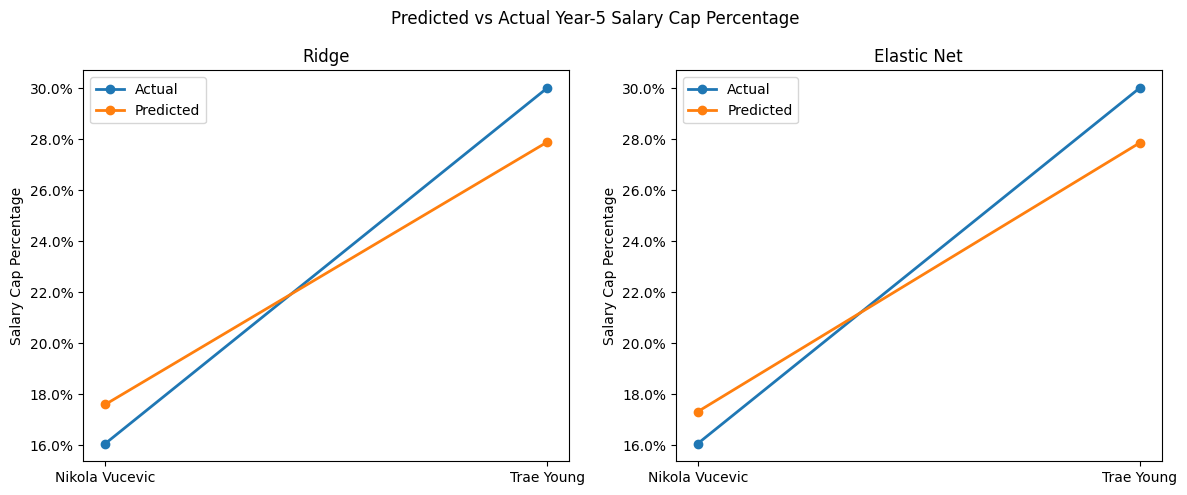

In [28]:


players = ["trae young", "nikola vucevic"]

ridge_two = cv_results_ridge_goal12.copy()
ridge_two["player_name_fixed"] = ridge_two["player_name_fixed"].str.strip().str.lower()
ridge_two = ridge_two[ridge_two["player_name_fixed"].isin(players)].copy()

enet_two = cv_results_enet_goal12.copy()
enet_two["player_name_fixed"] = enet_two["player_name_fixed"].str.strip().str.lower()
enet_two = enet_two[enet_two["player_name_fixed"].isin(players)].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Ridge
x1 = range(len(ridge_two))
axes[0].plot(x1, ridge_two["salary_cap_pct_y5"], marker="o", linewidth=2, label="Actual")
axes[0].plot(x1, ridge_two["pred_salary_cap_pct_y5"], marker="o", linewidth=2, label="Predicted")
axes[0].set_xticks(list(x1))
axes[0].set_xticklabels(ridge_two["player_name_fixed"].str.title(), rotation=0)
axes[0].set_title("Ridge")
axes[0].set_ylabel("Salary Cap Percentage")
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[0].legend()

# Elastic Net
x2 = range(len(enet_two))
axes[1].plot(x2, enet_two["salary_cap_pct_y5"], marker="o", linewidth=2, label="Actual")
axes[1].plot(x2, enet_two["pred_salary_cap_pct_y5"], marker="o", linewidth=2, label="Predicted")
axes[1].set_xticks(list(x2))
axes[1].set_xticklabels(enet_two["player_name_fixed"].str.title(), rotation=0)
axes[1].set_title("Elastic Net")
axes[1].set_ylabel("Salary Cap Percentage")
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].legend()

plt.suptitle("Predicted vs Actual Year-5 Salary Cap Percentage")
plt.tight_layout()
plt.show()

# Saving the result

In [29]:
# =========================================================
# 2. helpers
# =========================================================
manifest_rows = []

def add_manifest(file_key, file_name, plot_kind, title, x_col, y_cols, x_label="", y_label=""):
    manifest_rows.append({
        "file_key": file_key,
        "file_name": file_name,
        "plot_kind": plot_kind,
        "title": title,
        "x_col": x_col,
        "y_cols": "|".join(y_cols) if isinstance(y_cols, list) else y_cols,
        "x_label": x_label,
        "y_label": y_label
    })

def save_line_data(df, file_name, title, x_col="player_name_fixed",
                   actual_col="salary_cap_pct_y5", pred_col="pred_salary_cap_pct_y5",
                   extra_cols=None, x_label="", y_label="Salary Cap Percentage"):
    cols = [x_col, actual_col, pred_col]
    if extra_cols:
        cols += [c for c in extra_cols if c in df.columns]

    out = df[cols].copy()
    out = out.rename(columns={
        x_col: "x_label",
        actual_col: "actual",
        pred_col: "predicted"
    })
    out.to_csv(RESULT_DIR / file_name, index=False)

    add_manifest(
        file_key=file_name.replace(".csv", ""),
        file_name=file_name,
        plot_kind="line_actual_vs_predicted",
        title=title,
        x_col="x_label",
        y_cols=["actual", "predicted"],
        x_label=x_label,
        y_label=y_label
    )

def save_bar_data(df, file_name, title, x_col, ridge_col, enet_col, x_label="", y_label=""):
    out = df[[x_col, ridge_col, enet_col]].copy()
    out = out.rename(columns={
        x_col: "x_label",
        ridge_col: "Ridge",
        enet_col: "Elastic Net"
    })
    out.to_csv(RESULT_DIR / file_name, index=False)

    add_manifest(
        file_key=file_name.replace(".csv", ""),
        file_name=file_name,
        plot_kind="bar_ridge_vs_enet",
        title=title,
        x_col="x_label",
        y_cols=["Ridge", "Elastic Net"],
        x_label=x_label,
        y_label=y_label
    )

# =========================================================
# 3. selected 2 players data
# =========================================================
players = ["trae young", "nikola vucevic"]

ridge_two_save = cv_results_ridge_goal12.copy()
ridge_two_save["player_name_fixed"] = ridge_two_save["player_name_fixed"].str.strip().str.lower()
ridge_two_save = ridge_two_save[ridge_two_save["player_name_fixed"].isin(players)].copy()
ridge_two_save["player_name_fixed"] = ridge_two_save["player_name_fixed"].str.title()

enet_two_save = cv_results_enet_goal12.copy()
enet_two_save["player_name_fixed"] = enet_two_save["player_name_fixed"].str.strip().str.lower()
enet_two_save = enet_two_save[enet_two_save["player_name_fixed"].isin(players)].copy()
enet_two_save["player_name_fixed"] = enet_two_save["player_name_fixed"].str.title()

save_line_data(
    ridge_two_save,
    "selected_players_ridge_data.csv",
    "Predicted vs Actual Year-5 Salary Cap Percentage - Ridge",
    x_col="player_name_fixed"
)

save_line_data(
    enet_two_save,
    "selected_players_elastic_net_data.csv",
    "Predicted vs Actual Year-5 Salary Cap Percentage - Elastic Net",
    x_col="player_name_fixed"
)

# =========================================================
# 4. full-model sample plots data
#    these are the 4 line-plot datasets already used in notebook
# =========================================================
# title text uses already-computed model_summary so later py does not need to recompute
ridge_goal1_title = (
    f"Ridge + Goal 1 (feature)\n"
    f"Full Model: R² = {model_summary.loc['Ridge + Goal 1', 'R2']:.3f}, "
    f"RMSE = {model_summary.loc['Ridge + Goal 1', 'RMSE']:.3f}"
)

enet_goal1_title = (
    f"Elastic Net + Goal 1 (feature)\n"
    f"Full Model: R² = {model_summary.loc['Elastic Net + Goal 1', 'R2']:.3f}, "
    f"RMSE = {model_summary.loc['Elastic Net + Goal 1', 'RMSE']:.3f}"
)

ridge_goal12_title = (
    f"Ridge + Goal 1 + Goal 2 (feature)\n"
    f"Full Model: R² = {model_summary.loc['Ridge + Goal 1 + Goal 2', 'R2']:.3f}, "
    f"RMSE = {model_summary.loc['Ridge + Goal 1 + Goal 2', 'RMSE']:.3f}"
)

enet_goal12_title = (
    f"Elastic Net + Goal 1 + Goal 2 (feature)\n"
    f"Full Model: R² = {model_summary.loc['Elastic Net + Goal 1 + Goal 2', 'R2']:.3f}, "
    f"RMSE = {model_summary.loc['Elastic Net + Goal 1 + Goal 2', 'RMSE']:.3f}"
)

save_line_data(
    sample_20_players_ridge_goal1.copy(),
    "ridge_goal1_full_model_data.csv",
    ridge_goal1_title,
    x_col="player_name_fixed"
)

save_line_data(
    sample_20_players_enet_goal1.copy(),
    "elastic_net_goal1_full_model_data.csv",
    enet_goal1_title,
    x_col="player_name_fixed"
)

save_line_data(
    sample_20_players_ridge_goal12.copy(),
    "ridge_goal12_full_model_data.csv",
    ridge_goal12_title,
    x_col="player_name_fixed"
)

save_line_data(
    sample_20_players_enet_goal12.copy(),
    "elastic_net_goal12_full_model_data.csv",
    enet_goal12_title,
    x_col="player_name_fixed"
)

# =========================================================
# 5. top-5 combined bias-adjusted large-error plot data
#    from cell 31 logic
# =========================================================
class_map = {
    "Sleeper": "SL",
    "Neutral": "NEU",
    "Bust": "BU"
}

age_map = {
    "age_le_20": "≤20",
    "age_21_22": "21-22",
    "age_23_24": "23-24",
    "age_25_plus": "25+"
}

macro_map = {
    "High Scoring Bigs": "ScoreBig",
    "High-Usage Primary Creators": "Primary",
    "Low-Usage Interior Bigs": "Interior",
    "Two-Way Forwards": "2WayFwd",
    "Rim Pressure Drivers": "RimDrv",
    "Midrange Shot Creators": "MidShot"
}

shot_map = {
    "High Scoring Bigs": "ScoreBig",
    "High-Usage Primary Creators": "Primary",
    "Low-Usage Interior Bigs": "Interior",
    "Two-Way Forwards": "2WayFwd",
    "Rim Pressure Drivers": "RimDrv",
    "Midrange Shot Creators": "MidShot"
}

def shorten_combined_label_no_conf(s):
    parts = [p.strip() for p in str(s).split("|")]
    if len(parts) != 4:
        return str(s)
    cls, age, macro, shot = parts
    cls_s = class_map.get(cls, cls[:4])
    age_s = age_map.get(age, age)
    macro_s = macro_map.get(macro, macro[:10])
    shot_s = shot_map.get(shot, shot[:10])
    return f"{cls_s} | {age_s} | {macro_s} | {shot_s}"

top5_plot_df = top5_groups[
    [
        "combined_group",
        "group_size_ridge",
        "smoothed_error_pct_ridge",
        "group_size_enet",
        "smoothed_error_pct_enet"
    ]
].copy()

top5_plot_df["short_label"] = top5_plot_df["combined_group"].apply(shorten_combined_label_no_conf)
top5_plot_df["label"] = (
    top5_plot_df["short_label"]
    + "\n(R n=" + top5_plot_df["group_size_ridge"].astype(int).astype(str)
    + ", E n=" + top5_plot_df["group_size_enet"].astype(int).astype(str) + ")"
)

save_bar_data(
    top5_plot_df,
    "bias_top5_groups_large_error_data.csv",
    f"Top 5 Groups with Highest Bias-Adjusted Large-Error Percentage (|error| >= {threshold:.2f})",
    x_col="label",
    ridge_col="smoothed_error_pct_ridge",
    enet_col="smoothed_error_pct_enet",
    x_label="Group: Class | Age | Macro | Shot",
    y_label="Bias-adjusted percentage of players in group with large error (%)"
)

# =========================================================
# 6. by age group
# =========================================================
age_label_map = {
    "age_le_20": "≤20",
    "age_21_22": "21-22",
    "age_23_24": "23-24",
    "age_25_plus": "25+"
}

age_plot_df = age_compare.copy()
age_plot_df["age_label"] = age_plot_df["age_group"].astype(str).map(age_label_map)
age_plot_df["label"] = (
    age_plot_df["age_label"]
    + "\n(R n=" + age_plot_df["group_size_ridge"].astype(int).astype(str)
    + ", E n=" + age_plot_df["group_size_enet"].astype(int).astype(str) + ")"
)

save_bar_data(
    age_plot_df,
    "bias_by_age_group_data.csv",
    f"Bias-Adjusted Large-Error Percentage by Age Group (|error| >= {threshold:.2f})",
    x_col="label",
    ridge_col="smoothed_error_pct_ridge",
    enet_col="smoothed_error_pct_enet",
    x_label="Age Group",
    y_label="Bias-adjusted % of players in group with large error"
)

# =========================================================
# 7. by predicted class
# =========================================================
class_plot_df = class_compare.copy()
class_plot_df["label"] = (
    class_plot_df["predicted_class"].astype(str)
    + "\n(R n=" + class_plot_df["group_size_ridge"].astype(int).astype(str)
    + ", E n=" + class_plot_df["group_size_enet"].astype(int).astype(str) + ")"
)

save_bar_data(
    class_plot_df,
    "bias_by_predicted_class_data.csv",
    f"Bias-Adjusted Large-Error Percentage by Predicted Class (|error| >= {threshold:.2f})",
    x_col="label",
    ridge_col="smoothed_error_pct_ridge",
    enet_col="smoothed_error_pct_enet",
    x_label="Predicted Class",
    y_label="Bias-adjusted % of players in group with large error"
)

# =========================================================
# 8. by macro archetype
# =========================================================
macro_plot_df = macro_compare.copy()
macro_plot_df["label"] = (
    macro_plot_df["macro_archetype"].astype(str)
    + "\n(R n=" + macro_plot_df["group_size_ridge"].astype(int).astype(str)
    + ", E n=" + macro_plot_df["group_size_enet"].astype(int).astype(str) + ")"
)

save_bar_data(
    macro_plot_df,
    "bias_by_macro_archetype_data.csv",
    f"Bias-Adjusted Large-Error Percentage by Macro Archetype (|error| >= {threshold:.2f})",
    x_col="label",
    ridge_col="smoothed_error_pct_ridge",
    enet_col="smoothed_error_pct_enet",
    x_label="Macro Archetype",
    y_label="Bias-adjusted % of players in group with large error"
)

# =========================================================
# 9. by shot style subtype
# =========================================================
shot_plot_df = shot_compare.copy()
shot_plot_df["label"] = (
    shot_plot_df["shot_style_subtype"].astype(str)
    + "\n(R n=" + shot_plot_df["group_size_ridge"].astype(int).astype(str)
    + ", E n=" + shot_plot_df["group_size_enet"].astype(int).astype(str) + ")"
)

save_bar_data(
    shot_plot_df,
    "bias_by_shot_style_subtype_data.csv",
    f"Bias-Adjusted Large-Error Percentage by Shot Style Subtype (|error| >= {threshold:.2f})",
    x_col="label",
    ridge_col="smoothed_error_pct_ridge",
    enet_col="smoothed_error_pct_enet",
    x_label="Shot Style Subtype",
    y_label="Bias-adjusted % of players in group with large error"
)

# =========================================================
# 10. optional raw tables too
# =========================================================
model_summary.to_csv(RESULT_DIR / "model_summary_table.csv")
top5_groups.to_csv(RESULT_DIR / "top5_groups_full_table.csv", index=False)
age_compare.to_csv(RESULT_DIR / "age_compare_full_table.csv", index=False)
class_compare.to_csv(RESULT_DIR / "class_compare_full_table.csv", index=False)
macro_compare.to_csv(RESULT_DIR / "macro_compare_full_table.csv", index=False)
shot_compare.to_csv(RESULT_DIR / "shot_compare_full_table.csv", index=False)

# =========================================================
# 11. manifest
# =========================================================
manifest_df = pd.DataFrame(manifest_rows)
manifest_df.to_csv(RESULT_DIR / "plot_manifest.csv", index=False)

print("\nSaved chart-ready files:")
for x in sorted([p.name for p in RESULT_DIR.glob("*.csv")]):
    print("-", x)






Saved chart-ready files:
- age_compare_full_table.csv
- bias_by_age_group_data.csv
- bias_by_macro_archetype_data.csv
- bias_by_predicted_class_data.csv
- bias_by_shot_style_subtype_data.csv
- bias_top5_groups_large_error_data.csv
- class_compare_full_table.csv
- df_with_archetype_matched.csv
- df_y5.csv
- elastic_net_goal12_full_model_data.csv
- elastic_net_goal1_full_model_data.csv
- macro_compare_full_table.csv
- model_summary_table.csv
- plot_manifest.csv
- ridge_goal12_full_model_data.csv
- ridge_goal1_full_model_data.csv
- selected_players_elastic_net_data.csv
- selected_players_ridge_data.csv
- shot_compare_full_table.csv
- top5_groups_full_table.csv
